# EDIS 8100 · Week 10 · Game and Emotional Learning Analytics Lab

**Teaching and Learning Analytics · Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia**

Estimated time: about 50 minutes for the core path. Guest this week: Chaewon Kim, Florida State University.

Today the data changes underneath you. For nine weeks you have worked with 120 undergraduates in a blended course at Blue Ridge University. Close that file. This week you are looking at **FractionQuest**, a fractions game played by **200 middle schoolers in grades 6 and 7** during **October 2026**: eight levels, a pre-test and a post-test scored out of 20, an attempt by attempt play log, and in-game emotion self reports.

Everything else changes with it. The learners are children. The log is not a click trail through a course site, it is a minute-by-minute record of a child getting fractions wrong, attempt after attempt, until they got them right or stopped. And the outcome measure, unusually for this course, is an actual test of the thing the game was supposed to teach.

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. **Build a learning curve** from attempt level game telemetry, and explain why the pooled version of that curve points the wrong way while the per-level version does not.
2. **Locate a difficulty cliff** using four signals (errors, retries, completion, time), say what any one of them alone would have missed, and show why the comparison only holds once you hold the population of players fixed.
3. **Compare productive strugglers with fast finishers** on pre to post gains, and separate the claim "this group gained less" from the claim "this group had less to gain."
4. **Read an emotion self report stream as a sequence** rather than as a frequency table, and state what confusion that resolves and confusion that persists each predict.

## How this notebook works (read this if you are new to code)

- Run the cells **top to bottom** with **Shift+Enter**. Every cell assumes the ones above it have already run.
- **Nothing here can break your computer.** Nothing is uploaded, nothing is downloaded, and no real child is anywhere in this file.
- If something looks wrong, the fix is almost always **Runtime > Restart and run all** (Colab) or **Kernel > Restart & Run All** (Jupyter). Start there before debugging anything.
- The **✏️ Your turn** cells already contain working answers. The notebook runs start to finish without you typing a single character. Edit them when you are ready, not before.
- You are not expected to write this code from scratch. You are expected to be able to say what each chart licenses you to claim, which is the harder skill and the one this course grades.

Section markers you will see: 🎯 objectives · ⚙️ setup · 📊 analysis · ✏️ your turn · 💬 discuss · ✅ submit

## ⚙️ Setup: run the next cell first

The cell below builds this week's three synthetic datasets (`game_players.csv`, `game_telemetry.csv`, and `game_emotion.csv`) directly inside your Colab or Jupyter runtime. There is nothing to download and nothing to log into.

The data are synthetic **on purpose**, and this week that matters more than usual. These are records of eleven and twelve year olds struggling with fractions, complete with self reported frustration. No real child consented to be your homework, so we built a world instead and you get to rehearse the judgment without surveilling anyone. The ask in return is the same as every week: treat this data as if it were real.

In [1]:
# ⚙️ SETUP CELL. This is long on purpose, and you are not meant to read it.
# It is here so the notebook works in Colab with no downloads, no logins, and no network.
# Click the arrow at the left edge to collapse it, run it once, and move on.

"""EDIS 8100 data generation, the subset needed for week10.
Extracted verbatim from data/generate_all_data.py so the numbers match the
canonical course datasets exactly. Seeds and helper functions are unchanged.
"""
from __future__ import annotations
import argparse
import time
from pathlib import Path
import numpy as np
import pandas as pd

SEED = 8100
SEED_GAME_PLAYERS = SEED + 10
SEED_GAME_TELEMETRY = SEED + 11
SEED_GAME_EMOTION = SEED + 12
DEFAULT_OUTDIR = Path('data')
N_PLAYERS = 200
N_LEVELS = 8
def _outpath(outdir, filename: str) -> Path:
    path = Path(outdir).expanduser().resolve()
    path.mkdir(parents=True, exist_ok=True)
    return path / filename
def _iso(dt64) -> pd.Series:
    """Format datetime64 values as ISO 8601 strings without fractional seconds."""
    return pd.Series(pd.to_datetime(np.asarray(dt64))).dt.strftime("%Y-%m-%dT%H:%M:%S")
def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.asarray(x, dtype="float64")))
GAME_START = np.datetime64("2026-10-05T08:00:00")
# Latent play profiles. These names are the course speaking in its own voice, so each one
# describes a pattern of play in the log and not a kind of child. "stopped_early" is the
# profile whose players tend to leave the game after a few levels; it says what the trace
# looks like and stays silent on why, which is all a generator is entitled to say.
PROFILES = ["fast_finisher", "productive_struggler", "stopped_early", "steady"]
PROFILE_P = [0.24, 0.34, 0.20, 0.22]
def make_game_players(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """The 200 FractionQuest players, with pre and post fractions assessments.

    Latent play profiles are set here so that telemetry and emotion pings can be
    generated independently and still describe the same 200 children.

    P7: productive strugglers, who make moderate early errors and keep retrying,
    gain the most from pre to post, more than the error free fast finishers who
    were already near the top of the scale.
    """
    rng = np.random.default_rng(SEED_GAME_PLAYERS)
    n = N_PLAYERS

    player_id = np.array([f"P{i + 1:03d}" for i in range(n)])
    grade_level = rng.choice([6, 7], size=n, p=[0.5, 0.5])
    profile = rng.choice(PROFILES, size=n, p=PROFILE_P)

    ability = rng.normal(0, 1, n)
    persistence = rng.normal(0, 1, n)
    ability += np.select(
        [profile == "fast_finisher", profile == "productive_struggler",
         profile == "stopped_early", profile == "steady"],
        [0.85, 0.00, -0.45, 0.20],
    )
    persistence += np.select(
        [profile == "fast_finisher", profile == "productive_struggler",
         profile == "stopped_early", profile == "steady"],
        [0.25, 1.05, -1.15, 0.25],
    )
    ability = ability * 0.85
    error_tendency = np.select(
        [profile == "fast_finisher", profile == "productive_struggler",
         profile == "stopped_early", profile == "steady"],
        [-0.70, 0.35, 0.55, -0.15],
    ) + rng.normal(0, 0.35, n)

    confusion_resolves = (rng.random(n) < _sigmoid(0.95 * persistence + 0.35 * ability + 0.15)).astype(int)

    pre_score = np.clip(np.round(10.0 + 3.1 * ability + rng.normal(0, 1.9, n)), 0, 20).astype(int)

    gain_base = np.select(
        [profile == "fast_finisher", profile == "productive_struggler",
         profile == "stopped_early", profile == "steady"],
        [2.55, 3.75, 1.45, 2.85],
    )
    gain = (
        gain_base
        - 0.24 * (pre_score - 10.0)          # ceiling: less room at the top
        + 1.05 * confusion_resolves
        + 0.30 * persistence
        + rng.normal(0, 2.25, n)
    )
    post_score = np.clip(np.round(pre_score + gain), 0, 20).astype(int)

    df = pd.DataFrame(
        {
            "player_id": player_id,
            "grade_level": grade_level,
            "pre_score": pre_score,
            "post_score": post_score,
            # latent traits, not written to CSV
            "profile": profile,
            "ability": ability,
            "persistence": persistence,
            "error_tendency": error_tendency,
            "confusion_resolves": confusion_resolves,
        }
    )
    if write:
        df[["player_id", "grade_level", "pre_score", "post_score"]].to_csv(
            _outpath(outdir, "game_players.csv"), index=False
        )
    return df
LEVEL_DIFFICULTY = np.array([0.28, 0.40, 0.52, 1.02, 0.60, 0.70, 0.80, 0.90])
def make_game_telemetry(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Attempt level telemetry for the eight FractionQuest levels.

    P7 continues here: errors, attempts, and time all spike at level 4, and the
    players who keep retrying through it are the ones who gain the most.
    Players who run out of patience simply stop appearing in the log, which is
    the kind of missingness a game analyst has to notice on their own.
    """
    rng = np.random.default_rng(SEED_GAME_TELEMETRY)
    players = make_game_players(write=False)

    rows = []
    for _, p in players.iterrows():
        ability = float(p["ability"])
        persistence = float(p["persistence"])
        err_t = float(p["error_tendency"])
        resolves = int(p["confusion_resolves"])
        fast = p["profile"] == "fast_finisher"

        t = (
            GAME_START
            + np.timedelta64(int(rng.integers(0, 9)), "D")
            + np.timedelta64(int(rng.integers(0, 7 * 3600)), "s")
        )
        for level in range(1, N_LEVELS + 1):
            diff = float(LEVEL_DIFFICULTY[level - 1])
            patience = 1 + rng.poisson(max(0.30, 1.70 + 1.20 * persistence + 0.6 * diff))
            patience = int(np.clip(patience, 1, 8))
            completed_level = False

            for attempt in range(1, patience + 1):
                p_success = _sigmoid(
                    1.40 * ability - 3.00 * (diff - 0.30) + 0.60 * (attempt - 1) + 1.55
                )
                success = rng.random() < p_success
                err_lam = np.clip(
                    0.7 + 5.2 * diff * (1.0 - 0.28 * ability) + 0.9 * err_t - 0.55 * (attempt - 1),
                    0.15, None,
                )
                errors = int(rng.poisson(err_lam))
                if success:
                    errors = int(max(0, errors - rng.integers(0, 2)))
                hints = int(rng.poisson(np.clip(
                    0.35 + 1.9 * diff * (1.0 - 0.3 * ability) - (0.55 if fast else 0.0), 0.05, None
                )))
                time_s = float(np.round(np.exp(
                    3.55 + 0.85 * diff - 0.18 * ability + 0.045 * errors
                    - (0.28 if fast else 0.0) + rng.normal(0, 0.32)
                ), 1))

                rows.append(
                    {
                        "player_id": p["player_id"],
                        "grade_level": int(p["grade_level"]),
                        "level": level,
                        "attempt": attempt,
                        "time_s": time_s,
                        "errors": errors,
                        "hints_used": hints,
                        "completed": int(success),
                        "_ts": t,
                    }
                )
                t = t + np.timedelta64(int(time_s) + int(rng.integers(20, 200)), "s")
                if success:
                    completed_level = True
                    break

            if not completed_level:
                break  # ran out of patience and stopped playing

            # Between levels, some players simply do not come back.
            p_quit = _sigmoid(
                -3.20 - 0.85 * persistence + 1.15 * float(LEVEL_DIFFICULTY[min(level, N_LEVELS - 1)])
                - 0.70 * resolves
            )
            if level < N_LEVELS and rng.random() < p_quit:
                break
            if rng.random() < 0.45:
                t = t + np.timedelta64(int(rng.integers(6, 40)) * 3600, "s")

    df = pd.DataFrame(rows)
    df["timestamp"] = _iso(df["_ts"].to_numpy())
    df = df[["player_id", "grade_level", "level", "attempt", "time_s", "errors",
             "hints_used", "completed", "timestamp"]]
    if write:
        df.to_csv(_outpath(outdir, "game_telemetry.csv"), index=False)
    return df
EMOTIONS = ["interest", "confusion", "frustration", "boredom"]
def make_game_emotion(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """In game emotion self reports, sampled while each level is being played.

    P8: for players whose confusion resolves within about two levels, confusion
    is a productive signal and they gain. For players whose confusion never
    resolves, it keeps escalating and their last ping comes shortly before they
    stop playing altogether.
    """
    rng = np.random.default_rng(SEED_GAME_EMOTION)
    players = make_game_players(write=False)
    telemetry = make_game_telemetry(write=False)

    latents = players.set_index("player_id")
    tel = telemetry.copy()
    tel["ts"] = pd.to_datetime(tel["timestamp"])

    rows = []
    counter = 0
    for pid, sub in tel.groupby("player_id", sort=True):
        lat = latents.loc[pid]
        ability = float(lat["ability"])
        persistence = float(lat["persistence"])
        resolves = int(lat["confusion_resolves"])
        fast = lat["profile"] == "fast_finisher"

        levels = sorted(sub["level"].unique())
        max_level = max(levels)
        first_confusion = None

        for level in levels:
            lvl_rows = sub[sub["level"] == level]
            diff = float(LEVEL_DIFFICULTY[level - 1])
            attempts = int(lvl_rows["attempt"].max())
            mean_err = float(lvl_rows["errors"].mean())
            t0 = lvl_rows["ts"].min()
            t1 = lvl_rows["ts"].max()

            n_pings = int(rng.integers(1, 4))
            for _ in range(n_pings):
                w_interest = np.exp(0.85 + 0.45 * ability - 1.05 * diff + 0.25 * persistence)
                w_confusion = np.exp(-0.35 + 1.65 * diff - 0.55 * ability + 0.16 * mean_err)
                w_frustration = np.exp(-1.15 + 1.25 * diff + 0.30 * (attempts - 1) - 0.45 * persistence)
                w_boredom = np.exp(-0.85 - 1.35 * diff + (0.95 if fast else 0.0) - 0.25 * ability)

                # The P8 mechanism: resolved confusion fades after a level or two,
                # unresolved confusion keeps building and precedes quitting.
                if first_confusion is not None:
                    since = level - first_confusion
                    if resolves == 1 and since >= 1:
                        w_confusion *= 0.14
                        w_interest *= 1.55
                    elif resolves == 0:
                        w_confusion *= 1.9 + 0.5 * since
                        w_frustration *= 1.7 + 0.4 * since

                w = np.array([w_interest, w_confusion, w_frustration, w_boredom])
                w = w / w.sum()
                emotion = EMOTIONS[int(rng.choice(4, p=w))]
                if emotion == "confusion" and first_confusion is None:
                    first_confusion = level

                if emotion == "interest":
                    intensity = int(np.clip(rng.normal(3.5, 0.95), 1, 5))
                elif emotion == "confusion":
                    intensity = int(np.clip(rng.normal(3.0 + 0.55 * diff + 0.4 * (1 - resolves), 0.9), 1, 5))
                elif emotion == "frustration":
                    intensity = int(np.clip(rng.normal(3.1 + 0.6 * diff, 1.0), 1, 5))
                else:
                    intensity = int(np.clip(rng.normal(2.6, 0.95), 1, 5))

                span = max(60.0, (t1 - t0).total_seconds())
                ts = t0 + pd.Timedelta(seconds=float(rng.uniform(0, span)))
                counter += 1
                rows.append(
                    {
                        "player_id": pid,
                        "level": int(level),
                        "emotion": emotion,
                        "intensity": intensity,
                        "_ts": ts,
                    }
                )

        # Unresolved confusion right before a player disappears from the log.
        if first_confusion is not None and resolves == 0 and max_level < N_LEVELS:
            last = sub[sub["level"] == max_level]["ts"].max()
            counter += 1
            rows.append(
                {
                    "player_id": pid,
                    "level": int(max_level),
                    "emotion": "confusion",
                    "intensity": int(np.clip(rng.normal(4.2, 0.7), 1, 5)),
                    "_ts": last + pd.Timedelta(seconds=float(rng.uniform(5, 90))),
                }
            )

    df = pd.DataFrame(rows).sort_values(["_ts"], kind="stable").reset_index(drop=True)
    df["ping_id"] = [f"PG{i + 1:05d}" for i in range(len(df))]
    df["timestamp"] = pd.Series(df["_ts"]).dt.strftime("%Y-%m-%dT%H:%M:%S")
    df = df[["ping_id", "player_id", "level", "emotion", "intensity", "timestamp"]]
    if write:
        df.to_csv(_outpath(outdir, "game_emotion.csv"), index=False)
    return df


def build_data(outdir='data'):
    import os
    os.makedirs(outdir, exist_ok=True)
    make_game_players(outdir=outdir)
    make_game_telemetry(outdir=outdir)
    make_game_emotion(outdir=outdir)
    return outdir


build_data(outdir='data')
print('Data ready. Files created in ./data:')
import os
for f in sorted(os.listdir('data')): print('  ', f)


Data ready. Files created in ./data:
   game_emotion.csv
   game_players.csv
   game_telemetry.csv


## 📊 1. A new setting, and a new kind of learner

### FractionQuest, in one paragraph

FractionQuest is a fractions game. Two hundred students in grades 6 and 7 played it during October 2026. There are **eight levels**, each introducing a harder fraction idea. A player attempts a level, and the game logs how long the attempt took, how many errors they made, how many hints they pulled, and whether the attempt cleared the level. If it did not clear, they can attempt again. Every player took the **same 20 item fractions test before and after** playing.

Three files, three grains:

| File | One row is | Why we need it |
|---|---|---|
| `game_players.csv` | one player | the roster, plus the pre-test and post-test scores |
| `game_telemetry.csv` | one **attempt** at one level | the play log itself |
| `game_emotion.csv` | one **emotion ping** | what the player said they were feeling, in the moment |

An **emotion ping** is a small in-game prompt: the game pauses and asks the player to pick one of four words, *interest*, *confusion*, *frustration*, or *boredom*, and rate how strongly they feel it from 1 to 5. This is a self report method, and D'Mello and Jensen would want you to hold on to that phrase. Nothing here measures an emotion. It measures what a twelve year old was willing to click when a game interrupted them.

### The thing that changed this week

Every design proposal you have made in this course so far, the dashboards in Week 4, the risk-model audit in Week 3, the collaboration analytics in Week 9, was aimed at adults. Adults in a university, who enrolled voluntarily, who can read a privacy policy, and who could in principle walk into an office and object.

**These learners are children.** They did not choose the game, a teacher or a district did. They cannot meaningfully consent, and the adults who consented on their behalf were not the ones being logged. Their families may never learn that a record exists of how many times their child failed level 4 and how frustrated they said they were about it. And the data includes an emotional self report, which is about as intimate as educational telemetry gets.

Hold that in mind as you work. At the end of the notebook you will be asked to take one design proposal you have already made this semester and say what breaks when the user is eleven.

### Loading the three files

Three libraries do all the work today: **pandas** for tables, **numpy** for arithmetic, and **matplotlib** for pictures. Nothing else this week. If you have never seen them before, think of pandas as a spreadsheet you can talk to.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Readable defaults for every figure in this notebook.
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.30
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['font.size'] = 10
pd.set_option('display.width', 130)

# Colorblind-safe palette (Okabe and Ito). No red-versus-green anywhere in this notebook.
BLUE   = '#0072B2'   # productive strugglers, and "interest"
ORANGE = '#E69F00'   # fast finishers, level 4, and "confusion"
PINK   = '#CC79A7'   # "frustration"
GRAY   = '#999999'   # everyone else, and "boredom"
GREEN  = '#009E73'   # occasional third series
BLACK  = '#333333'

players   = pd.read_csv('data/game_players.csv')
telemetry = pd.read_csv('data/game_telemetry.csv')
emotion   = pd.read_csv('data/game_emotion.csv')

print('game_players.csv  ', players.shape,   'one row per player')
print('game_telemetry.csv', telemetry.shape, 'one row per attempt at a level')
print('game_emotion.csv  ', emotion.shape,   'one row per emotion ping')
print()
print('--- players (first 5 rows) ---')
print(players.head().to_string(index=False))
print()
print('--- telemetry (first 5 rows) ---')
print(telemetry.head().to_string(index=False))
print()
print('--- emotion (first 5 rows) ---')
print(emotion.head().to_string(index=False))

game_players.csv   (200, 4) one row per player
game_telemetry.csv (1428, 9) one row per attempt at a level
game_emotion.csv   (2175, 6) one row per emotion ping

--- players (first 5 rows) ---
player_id  grade_level  pre_score  post_score
     P001            7          9          12
     P002            6         15          13
     P003            6          6          11
     P004            7          9           7
     P005            6         17          20

--- telemetry (first 5 rows) ---
player_id  grade_level  level  attempt  time_s  errors  hints_used  completed           timestamp
     P001            7      1        1    43.2       5           1          1 2026-10-09T08:02:44
     P001            7      2        1    98.7       3           1          1 2026-10-09T18:04:56
     P001            7      3        1    85.0       7           0          1 2026-10-09T18:08:55
     P001            7      4        1   120.2       6           0          1 2026-10-09T18:12:48
     P0

### Who is still here? The first thing to check in any game dataset

Notice what `game_telemetry.csv` does **not** have: a column that says "this player quit." Players who stop playing simply stop appearing. That is how almost all voluntary-use log data works, and it is the single most common way a game analysis goes quietly wrong.

So before we compute anything about learning, we count who is left at each level.

Total players on the roster: 200

       players_reaching_level  pct_of_all_players  lost_since_previous_level
level                                                                       
1                         200               100.0                          0
2                         178                89.0                        -22
3                         160                80.0                        -18
4                         135                67.5                        -25
5                         108                54.0                        -27
6                          99                49.5                         -9
7                          88                44.0                        -11
8                          81                40.5                         -7

Median player stops after level: 5
Players who reach level 8      : 81 (40% of the roster)


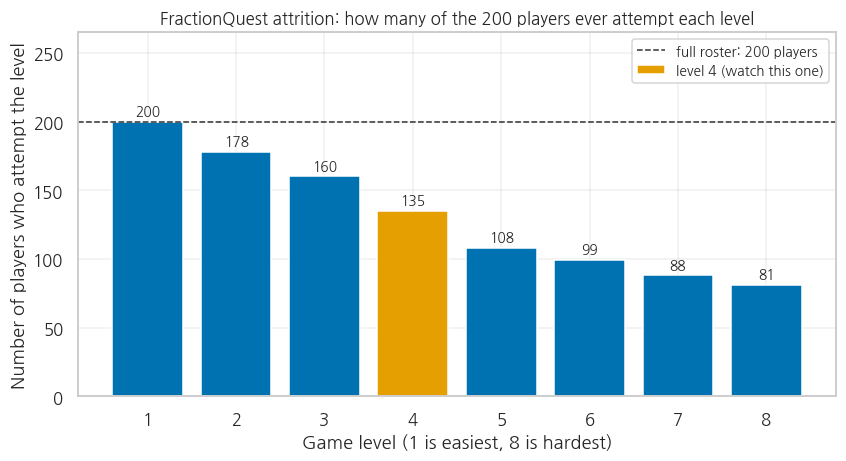

In [3]:
reached = telemetry.groupby('level')['player_id'].nunique()
n_players = players['player_id'].nunique()

attrition = pd.DataFrame({
    'players_reaching_level': reached,
    'pct_of_all_players': (100 * reached / n_players).round(1),
})
attrition['lost_since_previous_level'] = attrition['players_reaching_level'].diff().fillna(0).astype(int)

print('Total players on the roster:', n_players)
print()
print(attrition.to_string())

last_level = telemetry.groupby('player_id')['level'].max()
print()
print('Median player stops after level:', int(last_level.median()))
print('Players who reach level 8      :', int((last_level == 8).sum()),
      '(%.0f%% of the roster)' % (100 * (last_level == 8).mean()))

fig, ax = plt.subplots(figsize=(7.8, 4.3))
ax.bar(attrition.index, attrition['players_reaching_level'], color=BLUE, edgecolor='white')
ax.bar([4], [attrition.loc[4, 'players_reaching_level']], color=ORANGE, edgecolor='white',
       label='level 4 (watch this one)')
for lv, v in attrition['players_reaching_level'].items():
    ax.text(lv, v + 5, str(v), ha='center', fontsize=9)
ax.axhline(n_players, color=BLACK, linestyle='--', linewidth=1,
           label='full roster: %d players' % n_players)
ax.set_title('FractionQuest attrition: how many of the 200 players ever attempt each level')
ax.set_xlabel('Game level (1 is easiest, 8 is hardest)')
ax.set_ylabel('Number of players who attempt the level')
ax.set_xticks(range(1, 9))
ax.set_ylim(0, 265)
ax.legend(loc='upper right', frameon=True, fontsize=9)
plt.tight_layout()
plt.show()

**Interpretation prompt.** The roster is 200. Level 8 is attempted by 81 players. Everything you compute from level 5 onward describes a group that has already been filtered by weeks of quitting.

Answer these in a sentence each before scrolling:

1. Suppose average errors go *down* at levels 5 through 8. Give the encouraging reading, then give the deflating one. Which does this chart let you rule out?
2. A game studio's dashboard reports "average post-test gain among players who completed the game." Name the group that number is silently about, and say who is missing from it.
3. The single largest drop in this chart happens between two specific levels. Which two, and what is your first guess about why?

## 📊 2. Learning curves, and the one that lies

Reardon, Kumar, and Revelle put the **learning curve** near the center of game learning analytics: as a player gets more practice with a skill, their errors should fall. A curve that falls is evidence the game is teaching. A curve that is flat is evidence it is not.

Here the natural unit of practice is the **attempt**. A player attempts level 3, and if they do not clear it they attempt level 3 again. Attempt 2 is more practice than attempt 1. So mean errors should fall from attempt 1 to attempt 2 to attempt 3.

We will draw that curve three ways, and the three do not agree. Read all three panels before you read anything else.

- **Panel A** pools every attempt in the game, regardless of level. This is the curve most people draw first.
- **Panel B** draws one curve per level. Same data, split by where the attempt happened.
- **Panel C** puts every level on a common scale: each level's errors are divided by that level's own first-attempt average, so 1.0 means "as bad as a typical first try at this level" and 0.8 means "20 percent fewer errors than a typical first try here."

Panel A, pooled mean errors by attempt number:
         mean_errors  n_attempts
attempt                         
1               3.24        1049
2               3.60         282
3               3.58          74

Share of each attempt column that comes from level 4 alone:
  attempt 1: 13% of 1049 rows
  attempt 2: 23% of 282 rows
  attempt 3: 36% of 74 rows

Panel C, mean errors relative to each level's own first attempt:
         relative_errors  n_attempts
attempt                             
1                  1.000        1049
2                  0.941         282
3                  0.843          74

Panel C weights levels by how many attempts they contributed. Giving every level equal weight
instead is a different estimator, and a finding should survive the swap:
  attempt 1: 1.000 attempt-weighted, 1.000 level-weighted
  attempt 2: 0.941 attempt-weighted, 0.928 level-weighted
  attempt 3: 0.843 attempt-weighted, 0.808 level-weighted

And the reason a falling curve is not automati

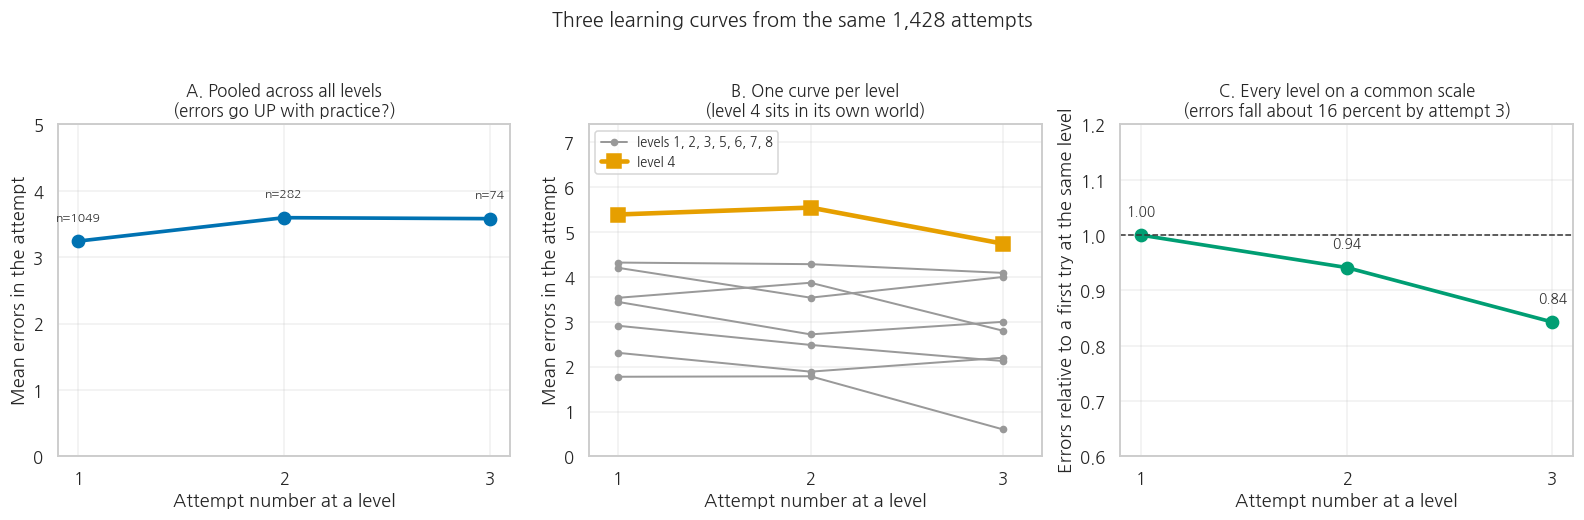

In [4]:
# Keep attempts 1 to 3. Beyond attempt 3 the cells get too thin to average honestly.
curve = telemetry[telemetry['attempt'] <= 3].copy()

# Panel A: pooled across all levels.
pooled = curve.groupby('attempt')['errors'].agg(['mean', 'size'])

# Panel B: one curve per level.
by_level = curve.pivot_table(index='attempt', columns='level', values='errors', aggfunc='mean')
cell_n   = curve.pivot_table(index='attempt', columns='level', values='errors', aggfunc='size')

# Panel C: each level rescaled by its own first-attempt mean, then averaged across levels.
first_attempt_mean = telemetry[telemetry['attempt'] == 1].groupby('level')['errors'].mean()
curve['errors_relative'] = curve['errors'] / curve['level'].map(first_attempt_mean)
relative = curve.groupby('attempt')['errors_relative'].agg(['mean', 'size'])

print('Panel A, pooled mean errors by attempt number:')
print(pooled.rename(columns={'mean': 'mean_errors', 'size': 'n_attempts'}).round(2).to_string())
print()
print('Share of each attempt column that comes from level 4 alone:')
for a in [1, 2, 3]:
    sub = telemetry[telemetry['attempt'] == a]
    print('  attempt %d: %.0f%% of %d rows' % (a, 100 * (sub['level'] == 4).mean(), len(sub)))
print()
print("Panel C, mean errors relative to each level's own first attempt:")
print(relative.rename(columns={'mean': 'relative_errors', 'size': 'n_attempts'}).round(3).to_string())
print()
print('Panel C weights levels by how many attempts they contributed. Giving every level equal weight')
print('instead is a different estimator, and a finding should survive the swap:')
per_level_rel = curve.groupby(['attempt', 'level'])['errors_relative'].mean()
for a in [1, 2, 3]:
    print('  attempt %d: %.3f attempt-weighted, %.3f level-weighted'
          % (a, relative.loc[a, 'mean'], per_level_rel.loc[a].mean()))
print()
print('And the reason a falling curve is not automatically learning:')
print('  errors on ALL first attempts                        : %.2f'
      % telemetry.loc[telemetry['attempt'] == 1, 'errors'].mean())
print('  errors on first attempts that went on to a second   : %.2f'
      % telemetry.loc[(telemetry['attempt'] == 1) & (telemetry['completed'] == 0), 'errors'].mean())
print('  A second attempt exists only because the first one failed, so the attempt-1 rows that')
print('  have an attempt-2 partner are selected to be bad ones. Some of the drop is that, not practice.')

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.5))

# --- Panel A
ax = axes[0]
ax.plot(pooled.index, pooled['mean'], marker='o', color=BLUE, linewidth=2.4, markersize=8)
for a, row in pooled.iterrows():
    ax.annotate('n=%d' % row['size'], (a, row['mean']), textcoords='offset points',
                xytext=(0, 13), ha='center', fontsize=8, color=BLACK)
ax.set_title('A. Pooled across all levels\n(errors go UP with practice?)')
ax.set_xlabel('Attempt number at a level')
ax.set_ylabel('Mean errors in the attempt')
ax.set_xticks([1, 2, 3])
ax.set_ylim(0, 5)

# --- Panel B
ax = axes[1]
for k, lv in enumerate([c for c in by_level.columns if c != 4]):
    keep = cell_n[lv] >= 5
    ax.plot(by_level.index[keep], by_level.loc[keep, lv], marker='o', color=GRAY,
            linewidth=1.3, markersize=4, zorder=2,
            label='levels 1, 2, 3, 5, 6, 7, 8' if k == 0 else None)
ax.plot(by_level.index, by_level[4], marker='s', color=ORANGE, linewidth=3, markersize=9,
        zorder=3, label='level 4')
ax.set_title('B. One curve per level\n(level 4 sits in its own world)')
ax.set_xlabel('Attempt number at a level')
ax.set_ylabel('Mean errors in the attempt')
ax.set_xticks([1, 2, 3])
ax.set_xlim(0.85, 3.2)
ax.set_ylim(0, 7.4)
ax.legend(loc='upper left', frameon=True, fontsize=8.5)

# --- Panel C
ax = axes[2]
ax.plot(relative.index, relative['mean'], marker='o', color=GREEN, linewidth=2.4, markersize=8)
ax.axhline(1.0, color=BLACK, linestyle='--', linewidth=1)
for a, row in relative.iterrows():
    ax.annotate('%.2f' % row['mean'], (a, row['mean']), textcoords='offset points',
                xytext=(0, 13), ha='center', fontsize=9, color=BLACK)
ax.set_title('C. Every level on a common scale\n(errors fall about 16 percent by attempt 3)')
ax.set_xlabel('Attempt number at a level')
ax.set_ylabel('Errors relative to a first try at the same level')
ax.set_xticks([1, 2, 3])
ax.set_ylim(0.6, 1.2)

fig.suptitle('Three learning curves from the same 1,428 attempts', fontsize=13, y=1.04)
plt.tight_layout()
plt.show()

**Interpretation prompt. Do not skip this one, it is the methodological spine of the session.**

Panel A says errors rise from 3.24 on first attempts to 3.60 on second attempts. Panel C says errors fall to 0.84 of a first try by attempt 3. Both are arithmetically correct on the same 1,428 rows.

The reason is printed above the figure: level 4 supplies 13 percent of all first attempts but 36 percent of all third attempts. Panel A is not measuring practice. It is measuring **which levels people are still fighting with by the time they reach attempt 3.**

1. Say in one sentence what Panel A actually measured. Use the word "composition."
2. Panel A is what you get from `groupby('attempt')`. That is a single line of code and a plausible-looking chart. What is the general lesson about pooled averages over a variable that also decides who ends up in each bin?
3. Panel C is a defensible learning curve, and it still has **two** selection problems inside it. The first: who is in the attempt-3 row at all? The second is quieter and printed above the figure. A second attempt only exists because the first one failed, so every attempt-1 row that has an attempt-2 partner was, by construction, a bad first attempt: 4.35 errors against 3.24 for first attempts in general. Some of the fall from attempt 1 to attempt 2 is therefore the ordinary tendency of an unusually bad measurement to be followed by a less extreme one, which has a name you will meet again in section 4.1. Why is "errors fell 16 percent" still not the same as "players learned"?
4. Reardon, Kumar, and Revelle argue that game telemetry gives learning analytics something a course platform cannot: many repeated, tightly specified opportunities at the same skill. Looking at Panel B, what does this game's grain buy you, and where does it run out?

### ✏️ Your turn 1

Errors are one measure of struggle. Time and hints are two more, and they do not have to agree.

Change `CURVE_METRIC` to `'time_s'` or `'hints_used'` and rerun. The default is `'errors'`, so the cell runs untouched if you would rather just look.

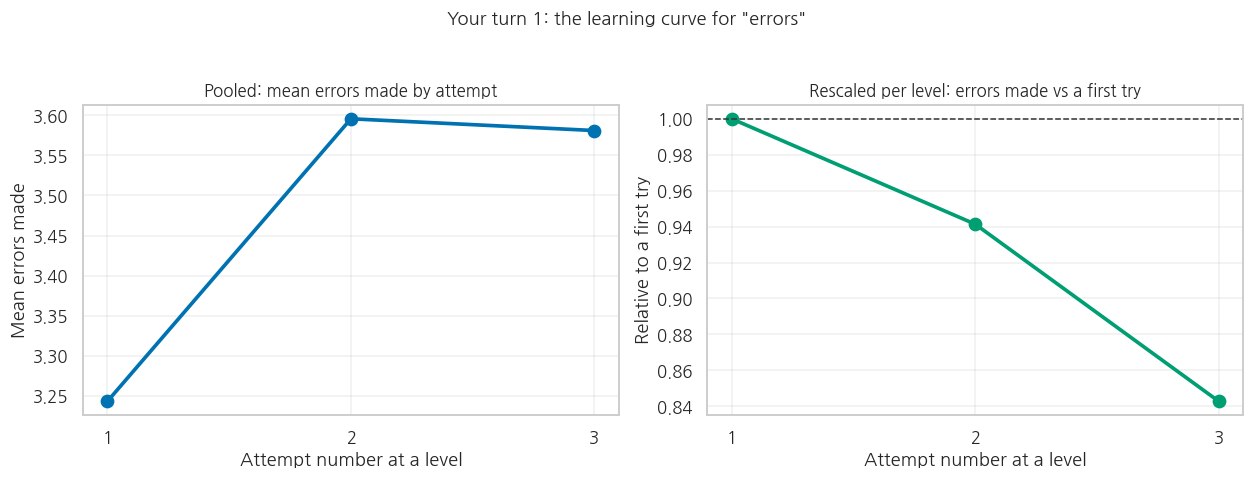

Pooled means  : {1: 3.24, 2: 3.6, 3: 3.58}
Rescaled means: {1: 1.0, 2: 0.941, 3: 0.843}


In [5]:
# ✏️ TODO: change this to 'time_s' or 'hints_used' and rerun the cell.
CURVE_METRIC = 'errors'        # working default: the notebook runs as is

LABELS = {'errors': 'errors made', 'time_s': 'seconds spent', 'hints_used': 'hints requested'}

yt = telemetry[telemetry['attempt'] <= 3].copy()
base = telemetry[telemetry['attempt'] == 1].groupby('level')[CURVE_METRIC].mean()
yt['rel'] = yt[CURVE_METRIC] / yt['level'].map(base)

yt_pooled = yt.groupby('attempt')[CURVE_METRIC].mean()
yt_rel    = yt.groupby('attempt')['rel'].mean()

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.1))
axes[0].plot(yt_pooled.index, yt_pooled.values, marker='o', color=BLUE, linewidth=2.4, markersize=8)
axes[0].set_title('Pooled: mean %s by attempt' % LABELS[CURVE_METRIC])
axes[0].set_xlabel('Attempt number at a level')
axes[0].set_ylabel('Mean %s' % LABELS[CURVE_METRIC])
axes[0].set_xticks([1, 2, 3])

axes[1].plot(yt_rel.index, yt_rel.values, marker='o', color=GREEN, linewidth=2.4, markersize=8)
axes[1].axhline(1.0, color=BLACK, linestyle='--', linewidth=1)
axes[1].set_title('Rescaled per level: %s vs a first try' % LABELS[CURVE_METRIC])
axes[1].set_xlabel('Attempt number at a level')
axes[1].set_ylabel('Relative to a first try')
axes[1].set_xticks([1, 2, 3])

fig.suptitle('Your turn 1: the learning curve for "%s"' % CURVE_METRIC, fontsize=12, y=1.05)
plt.tight_layout()
plt.show()

print('Pooled means  :', yt_pooled.round(2).to_dict())
print('Rescaled means:', yt_rel.round(3).to_dict())

**Interpretation prompt.** Whichever metric you chose, compare the two panels, and then compare the metric to `errors`.

1. Does rescaling change the direction of the curve for your metric the way it did for errors? If not, what does that tell you about whether the composition problem from section 2 was the only thing going on?
2. Suppose the second attempt at a level takes *longer* than the first and produces *fewer* errors. Write the sentence describing that child. Is it a sentence about struggle, or about strategy?
3. A vendor builds a single "struggle score" out of errors, time, and hints. Given what you just saw, what has that score assumed?

## 📊 3. The difficulty cliff

Panel B put level 4 in its own world. Now we ask whether that is one metric misbehaving or a real feature of the game.

The usual way to make this argument is with **signals that could disagree and do not**. We compute four per level:

| Signal | What it counts | What a cliff would look like |
|---|---|---|
| mean errors per attempt | mistakes inside one try | a spike |
| attempts per player | how often people had to retry | a spike |
| per-attempt completion rate | share of tries that cleared the level | a dip |
| mean seconds per attempt | how long a try took | a spike |

Before you enjoy that too much, two warnings, and the cell below prints the evidence for both.

**These four are not four independent measurements.** A failed attempt is what produces a retry, so
attempts per player is very nearly one divided by the completion rate, and the two track each other
across levels at r = 0.98. Errors and time track each other at r = 0.99. Four agreeing signals sound
like four votes. They are closer to one vote reported four ways, and describing them as independent
would be the kind of sentence that gets a paper accepted and is still wrong.

**Each level is played by a different set of children.** Level 4 is attempted by 135 players and
level 5 by 108, and the 27 who are missing are not a random 27: they are disproportionately the
players who had the hardest time at level 4. So comparing level 4 against level 5 compares a mixed
population against its own survivors, which biases the comparison *towards* finding a cliff at 4. The
fix is to stop letting the population change. The cell recomputes the neighbour comparison on the
**fixed cohort of 108 players who reached level 5**, and then does the strictest version available
here: for those same players, their own first-attempt errors at level 3, level 4, and level 5, compared
child by child.

In [6]:
level_summary = telemetry.groupby('level').agg(
    players_reaching=('player_id', 'nunique'),
    total_attempts=('attempt', 'size'),
    mean_errors=('errors', 'mean'),
    mean_time_s=('time_s', 'mean'),
    mean_hints=('hints_used', 'mean'),
    completion_rate=('completed', 'mean'),
)
level_summary['attempts_per_player'] = level_summary['total_attempts'] / level_summary['players_reaching']
level_summary = level_summary[['players_reaching', 'total_attempts', 'attempts_per_player',
                               'mean_errors', 'mean_time_s', 'mean_hints', 'completion_rate']]

print('Per-level summary, all 1,428 attempts:')
print(level_summary.round(3).to_string())

# Compare each level against the average of its two neighbours.
print()
print('Each level against the average of its immediate neighbours (errors):')
for lv in range(2, 8):
    neighbours = (level_summary.loc[lv - 1, 'mean_errors'] + level_summary.loc[lv + 1, 'mean_errors']) / 2
    print('  level %d: %.2f errors vs %.2f for levels %d and %d  ->  %.2f times the neighbours'
          % (lv, level_summary.loc[lv, 'mean_errors'], neighbours, lv - 1, lv + 1,
             level_summary.loc[lv, 'mean_errors'] / neighbours))

# --- Warning 1: the four signals are not four independent measurements.
print()
print('How independent are the four signals? (correlations across the eight levels)')
print('  attempts per player vs 1 / completion rate : r = %.2f'
      % np.corrcoef(level_summary['attempts_per_player'], 1 / level_summary['completion_rate'])[0, 1])
print('  mean errors vs mean seconds               : r = %.2f'
      % np.corrcoef(level_summary['mean_errors'], level_summary['mean_time_s'])[0, 1])
print('  A failed attempt is what causes a retry, so two of these are close to the same number.')

# --- Warning 2: hold the population fixed. Only the 108 players who reached level 5.
cohort = telemetry[telemetry['player_id'].isin(
    telemetry.loc[telemetry['level'] >= 5, 'player_id'].unique())]
fixed = cohort[cohort['level'] <= 5].groupby('level').agg(
    mean_errors=('errors', 'mean'),
    completion_rate=('completed', 'mean'),
    mean_time_s=('time_s', 'mean'),
    total_attempts=('attempt', 'size'),
    players=('player_id', 'nunique'),
)
fixed['attempts_per_player'] = fixed['total_attempts'] / fixed['players']

print()
print('Levels 1 to 5 for the fixed cohort of %d players who all reached level 5:'
      % cohort['player_id'].nunique())
print(fixed[['players', 'mean_errors', 'attempts_per_player', 'completion_rate',
             'mean_time_s']].round(3).to_string())
print()
print('Level 4 against the average of levels 3 and 5, population held constant:')
for col in ['mean_errors', 'attempts_per_player', 'completion_rate', 'mean_time_s']:
    print('  %-20s %.2f times the neighbour average'
          % (col, fixed.loc[4, col] / fixed.loc[[3, 5], col].mean()))

# --- The strictest version: each child compared against themselves.
first_try = telemetry[telemetry['attempt'] == 1].pivot_table(
    index='player_id', columns='level', values='errors')
paired = first_try[[3, 4, 5]].dropna()
own_diff = paired[4] - (paired[3] + paired[5]) / 2
print()
print('Strictest version: first-attempt errors for the %d children who tried all of levels 3, 4 and 5.'
      % len(paired))
print('  level 3: %.2f   level 4: %.2f   level 5: %.2f' % (paired[3].mean(), paired[4].mean(), paired[5].mean()))
print('  Each child minus their own levels 3 and 5 average: %+.2f errors '
      '(95%% interval %+.2f to %+.2f).'
      % (own_diff.mean(),
         own_diff.mean() - 1.96 * own_diff.std(ddof=1) / np.sqrt(len(own_diff)),
         own_diff.mean() + 1.96 * own_diff.std(ddof=1) / np.sqrt(len(own_diff))))
print('  %d of %d children made more errors at level 4 than at their own levels 3 and 5 average.'
      % (int((own_diff > 0).sum()), len(own_diff)))

Per-level summary, all 1,428 attempts:
       players_reaching  total_attempts  attempts_per_player  mean_errors  mean_time_s  mean_hints  completion_rate
level                                                                                                              
1                   200             233                1.165        1.751       47.812       0.721            0.807
2                   178             210                1.180        2.252       53.832       0.867            0.786
3                   160             205                1.281        2.829       62.450       1.190            0.707
4                   135             233                1.726        5.322      105.796       2.082            0.502
5                   108             140                1.296        3.343       64.580       1.393            0.764
6                    99             135                1.364        3.585       75.054       1.504            0.696
7                    88          

The cliff survives both checks, which is the reason we can keep talking about it: it is not an artifact
of who was still playing, and it is not one metric misbehaving. Four panels below, one per signal, with
level 4 marked in orange in each. Read them as four views of the same attempts rather than as four
independent votes.

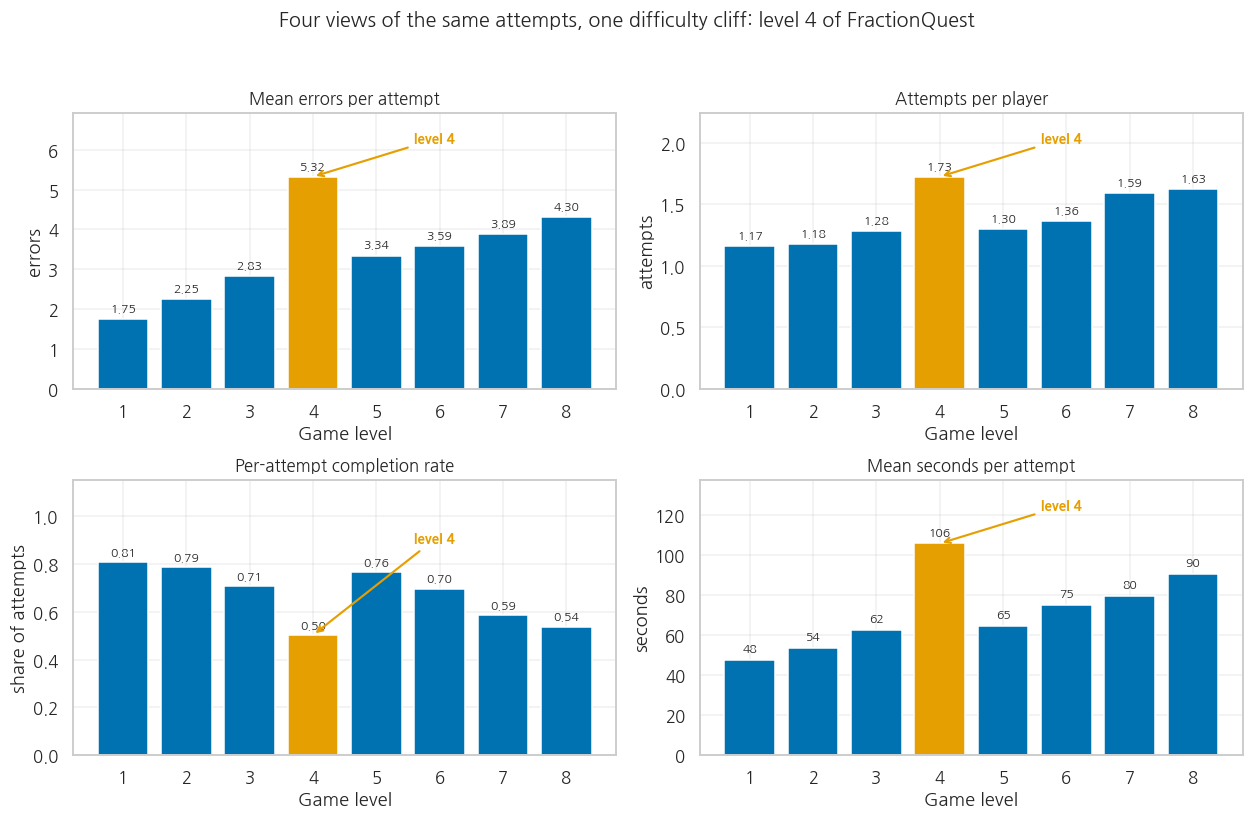

In [7]:
panels = [
    ('mean_errors',         'Mean errors per attempt',     'errors',            False),
    ('attempts_per_player', 'Attempts per player',         'attempts',          False),
    ('completion_rate',     'Per-attempt completion rate', 'share of attempts', True),
    ('mean_time_s',         'Mean seconds per attempt',    'seconds',           False),
]

fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.4))
for ax, (col, title, ylab, is_rate) in zip(axes.ravel(), panels):
    colors = [ORANGE if lv == 4 else BLUE for lv in level_summary.index]
    ax.bar(level_summary.index, level_summary[col], color=colors, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Game level')
    ax.set_ylabel(ylab)
    ax.set_xticks(range(1, 9))
    top = level_summary[col].max()
    ax.set_ylim(0, 1.15 if is_rate else top * 1.30)
    for lv, v in level_summary[col].items():
        ax.text(lv, v + top * 0.035, ('%.2f' % v) if v < 10 else ('%.0f' % v),
                ha='center', fontsize=8)
    ax.annotate('level 4', xy=(4, level_summary.loc[4, col]),
                xytext=(5.6, top * (1.10 if is_rate else 1.16)),
                fontsize=9, color=ORANGE, weight='bold',
                arrowprops=dict(arrowstyle='->', color=ORANGE, linewidth=1.4))

fig.suptitle('Four views of the same attempts, one difficulty cliff: level 4 of FractionQuest',
             fontsize=13, y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.965])
plt.show()

**Interpretation prompt.** Errors at level 4 run about 1.7 times the average of levels 3 and 5. Players need 1.73 attempts each instead of about 1.3. Half of all attempts at level 4 fail, against roughly three quarters succeeding at levels 3 and 5. And attempts take nearly twice as long. On the fixed cohort of 108 the ratios barely move, and child by child, level 4 costs the same children about two extra errors than their own levels 3 and 5 average, with an interval nowhere near zero.

1. Write the finding as one sentence a game designer could act on Monday. Then write the sentence you would put in a paper, which is not the same sentence. Which population does each sentence quantify over?
2. Levels 7 and 8 also show elevated errors and low completion. Why is calling *those* a cliff a weaker claim than calling level 4 a cliff? Look back at the attrition chart before you answer, and note that the fixed-cohort trick used here cannot be run for level 7 without shrinking the cohort to the 81 who finished.
3. This chart cannot tell you **why** level 4 is hard. Name two candidate explanations that live in the game's design and one that lives in the curriculum the players came from. What data would separate them?
4. Suppose your dashboard flags level 4 automatically and a district asks the vendor to remove it. What has the district actually removed, and who benefits?

### ✏️ Your turn 2

Level 4 is the loudest, but the neighbour comparison above is a general tool. Point it at another level.

`SPOTLIGHT_LEVEL` is set to 4, which reproduces the finding. Change it to 7 and see whether the same four signals still agree.

Level 4 against levels 3 and 5
       mean_errors  attempts_per_player  completion_rate  mean_time_s
level                                                                
4            5.322                1.726            0.502      105.796
3            2.829                1.281            0.707       62.450
5            3.343                1.296            0.764       64.580

  mean_errors          1.72 times the neighbour average (higher)
  attempts_per_player  1.34 times the neighbour average (higher)
  completion_rate      0.68 times the neighbour average (lower)
  mean_time_s          1.67 times the neighbour average (higher)


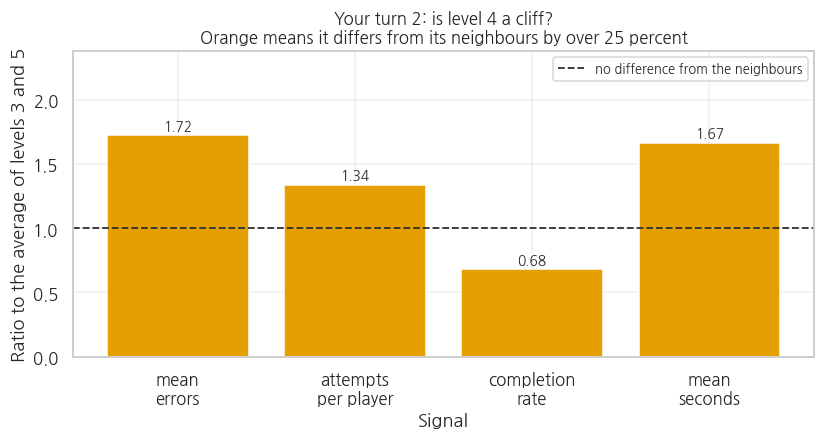

In [8]:
# ✏️ TODO: change the spotlight level (2 through 7 work; the comparison needs both neighbours).
SPOTLIGHT_LEVEL = 4            # working default: the notebook runs as is

lv = SPOTLIGHT_LEVEL
neighbours = [lv - 1, lv + 1]
compare = level_summary.loc[[lv] + neighbours,
                            ['mean_errors', 'attempts_per_player', 'completion_rate', 'mean_time_s']]

print('Level %d against levels %d and %d' % (lv, neighbours[0], neighbours[1]))
print(compare.round(3).to_string())
print()
ratios = []
for col in compare.columns:
    ratio = compare.loc[lv, col] / compare.loc[neighbours, col].mean()
    ratios.append(ratio)
    print('  %-20s %.2f times the neighbour average (%s)'
          % (col, ratio, 'higher' if ratio > 1 else 'lower'))

fig, ax = plt.subplots(figsize=(7.6, 4.1))
bar_colors = [ORANGE if abs(r - 1) > 0.25 else GRAY for r in ratios]
ax.bar(range(len(ratios)), ratios, color=bar_colors, edgecolor='white')
ax.axhline(1.0, color=BLACK, linestyle='--', linewidth=1.2,
           label='no difference from the neighbours')
for i, r in enumerate(ratios):
    ax.text(i, r + 0.04, '%.2f' % r, ha='center', fontsize=9)
ax.set_xticks(range(len(ratios)))
ax.set_xticklabels(['mean\nerrors', 'attempts\nper player', 'completion\nrate', 'mean\nseconds'])
ax.set_ylabel('Ratio to the average of levels %d and %d' % (neighbours[0], neighbours[1]))
ax.set_xlabel('Signal')
ax.set_ylim(0, max(ratios) * 1.38)
ax.legend(loc='upper right', fontsize=8.5, frameon=True)
ax.set_title('Your turn 2: is level %d a cliff?\nOrange means it differs from its neighbours by over 25 percent' % lv)
plt.tight_layout()
plt.show()

**Interpretation prompt.** How many of the four signals crossed the 25 percent line for the level you chose? A cliff that shows up on one signal and not the others is usually a measurement artifact rather than a design problem. Which of the four would you trust least on its own, and why?

Then the harder question, given what the previous cell printed. Two of these four are close to arithmetic restatements of each other, so "three of four crossed the line" is not three pieces of evidence. Which pair would you collapse, and does your answer for your chosen level survive the collapse?

## 📊 4. Productive strugglers and fast finishers

Now the question the whole week is built around. Two children play FractionQuest.

- One of them makes a lot of mistakes in the first four levels, fails a level, and comes back to try it again.
- The other sails through the first four levels quickly, with few errors and no retries.

Which one learned more fractions?

Almost every dashboard you have seen this semester would answer the second child, and would say so in green. Let us actually check, using the pre-test and post-test.

### Two decisions before we compute anything

**Decision 1: who is eligible for the comparison.** We restrict to the **135 players who reached level 4**. Otherwise "few errors and no retries" would include a child who quit at level 2, and the comparison would be about quitting rather than about how people play.

**Decision 2: what window we measure.** We use **levels 1 through 4 only**, the stretch of game that all 135 played. Measuring struggle over "the whole game" would mean measuring a longer game for the players who lasted longer.

Both decisions are ours, not the data's. Write them down, because Your Turn 3 lets you move them and see how much of the finding is yours rather than the world's.

### The definitions

> **Productive strugglers**: made **more errors than the median player** across levels 1 to 4, **and** retried at least one level.
>
> **Fast finishers**: made errors in the **bottom third** across levels 1 to 4, **and** never retried a level.
>
> **Everyone else**: the players who satisfy neither definition. They stay in the charts, because dropping them would be a choice too.

Nobody in this game is literally error free, so "fast finisher" here means the closest thing this data has to the error-free speedrunner of the games literature.

Both names describe a pattern in a play log and neither describes a kind of child. Nothing that follows
licenses a sentence about what a fast finisher is like, and section 4.1 will show you that the most
obvious such sentence is not even supported by the arithmetic.

In [9]:
# --- Build one row per player from levels 1 to 4 only.
early = telemetry[telemetry['level'] <= 4]

feat = early.groupby('player_id').agg(
    errors_1_4=('errors', 'sum'),
    attempts_1_4=('attempt', 'size'),
    time_1_4=('time_s', 'sum'),
    hints_1_4=('hints_used', 'sum'),
).reset_index()
feat['levels_1_4'] = early.groupby('player_id')['level'].nunique().values
feat['retries_1_4'] = feat['attempts_1_4'] - feat['levels_1_4']

deepest = telemetry.groupby('player_id')['level'].max().rename('max_level').reset_index()

play = players.merge(feat, on='player_id').merge(deepest, on='player_id')
play['gain'] = play['post_score'] - play['pre_score']

# Eligibility: reached level 4, so everyone in the comparison played the same stretch of game.
eligible = play[play['levels_1_4'] == 4].copy()
print('Players who reached level 4 and are eligible for this comparison:', len(eligible))

# --- Thresholds, printed so you can see exactly what they are.
ERROR_HIGH = eligible['errors_1_4'].median()          # above this = "more errors than the median"
ERROR_LOW  = eligible['errors_1_4'].quantile(0.33)    # at or below this = "bottom third"
print('Median errors across levels 1 to 4      : %.1f' % ERROR_HIGH)
print('33rd percentile of errors, levels 1 to 4: %.1f' % ERROR_LOW)


def label_player(row):
    if row['errors_1_4'] > ERROR_HIGH and row['retries_1_4'] >= 1:
        return 'Productive strugglers'
    if row['errors_1_4'] <= ERROR_LOW and row['retries_1_4'] == 0:
        return 'Fast finishers'
    return 'Everyone else'


eligible['group'] = eligible.apply(label_player, axis=1)
GROUP_ORDER = ['Productive strugglers', 'Fast finishers', 'Everyone else']
GROUP_COLOR = {'Productive strugglers': BLUE, 'Fast finishers': ORANGE, 'Everyone else': GRAY}

profile = eligible.groupby('group').agg(
    n=('player_id', 'size'),
    errors_1_4=('errors_1_4', 'mean'),
    retries_1_4=('retries_1_4', 'mean'),
    minutes_1_4=('time_1_4', lambda s: s.mean() / 60),
    hints_1_4=('hints_1_4', 'mean'),
    deepest_level=('max_level', 'mean'),
    pre_score=('pre_score', 'mean'),
    post_score=('post_score', 'mean'),
    gain=('gain', 'mean'),
).loc[GROUP_ORDER]

print()
print('How the three groups played levels 1 to 4, and how they scored:')
print(profile.round(2).to_string())

Players who reached level 4 and are eligible for this comparison: 135
Median errors across levels 1 to 4      : 16.0
33rd percentile of errors, levels 1 to 4: 13.0

How the three groups played levels 1 to 4, and how they scored:
                        n  errors_1_4  retries_1_4  minutes_1_4  hints_1_4  deepest_level  pre_score  post_score  gain
group                                                                                                                 
Productive strugglers  59       25.39         2.36         8.61       9.46           6.63       9.68       13.85  4.17
Fast finishers         36        7.97         0.00         3.40       3.64           7.03      14.14       16.61  2.47
Everyone else          40       13.38         0.92         5.37       5.68           6.80      11.38       14.30  2.92


Look at `deepest_level` in that table before you look at anything else. The two groups end up at essentially the same place in the game, so whatever we are about to see is not a story about one group quitting sooner. Look at `minutes_1_4` too: the fast finishers really are fast, by a factor of about two and a half.

Now the outcome. Two panels: where each group started and finished on the 20 item test, and the full spread of individual gains.

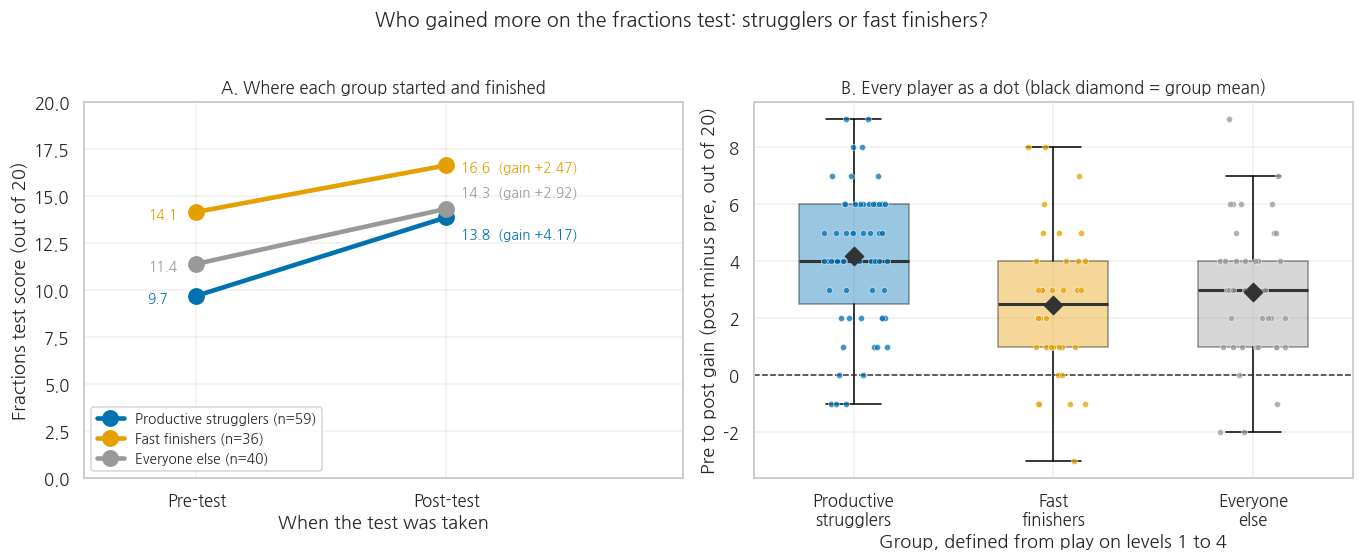

Mean gain, productive strugglers: 4.17 points (n=59)
Mean gain, fast finishers       : 2.47 points (n=36)
Difference                      : 1.70 points, in favour of the strugglers
Cohen's d                       : 0.69  (95% interval 0.26 to 1.11)


In [10]:
def cohens_d(a, b):
    # Standardized difference between two groups, using the sample-size weighted pooled
    # standard deviation (not the unweighted average of the two variances, which would be
    # wrong here because the groups differ in size).
    na, nb = len(a), len(b)
    pooled = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled


def d_interval(a, b):
    # Approximate 95 percent interval for Cohen's d. With groups this small the interval is
    # wide, and quoting d without it invites everyone to read it as a precise quantity.
    dd, na, nb = cohens_d(a, b), len(a), len(b)
    se = np.sqrt((na + nb) / (na * nb) + dd ** 2 / (2 * (na + nb)))
    return dd - 1.96 * se, dd + 1.96 * se


fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.9))

# --- Panel A: pre to post slope per group
ax = axes[0]
# Nudge the post-test labels apart: the strugglers and "everyone else" land within half a point.
POST_LABEL_OFFSET = {'Productive strugglers': -14, 'Fast finishers': -4, 'Everyone else': 8}
for g in GROUP_ORDER:
    row = profile.loc[g]
    ax.plot([0, 1], [row['pre_score'], row['post_score']], marker='o', markersize=10,
            linewidth=3, color=GROUP_COLOR[g], label='%s (n=%d)' % (g, row['n']))
    ax.annotate('%.1f' % row['pre_score'], (0, row['pre_score']), textcoords='offset points',
                xytext=(-32, -4), fontsize=9, color=GROUP_COLOR[g])
    ax.annotate('%.1f  (gain %+.2f)' % (row['post_score'], row['gain']), (1, row['post_score']),
                textcoords='offset points', xytext=(10, POST_LABEL_OFFSET[g]),
                fontsize=9, color=GROUP_COLOR[g])
ax.set_xticks([0, 1])
ax.set_xticklabels(['Pre-test', 'Post-test'])
ax.set_xlim(-0.45, 1.95)
ax.set_ylim(0, 20)
ax.set_ylabel('Fractions test score (out of 20)')
ax.set_xlabel('When the test was taken')
ax.set_title('A. Where each group started and finished')
ax.legend(loc='lower left', fontsize=9, frameon=True)

# --- Panel B: distribution of individual gains
ax = axes[1]
data = [eligible.loc[eligible['group'] == g, 'gain'].values for g in GROUP_ORDER]
bp = ax.boxplot(data, widths=0.55, patch_artist=True, showfliers=False,
                medianprops=dict(color=BLACK, linewidth=2))
for patch, g in zip(bp['boxes'], GROUP_ORDER):
    patch.set_facecolor(GROUP_COLOR[g])
    patch.set_alpha(0.40)
rng = np.random.default_rng(8100)
for i, g in enumerate(GROUP_ORDER):
    vals = eligible.loc[eligible['group'] == g, 'gain'].values
    ax.scatter(np.full(len(vals), i + 1) + rng.uniform(-0.17, 0.17, len(vals)), vals,
               s=16, color=GROUP_COLOR[g], alpha=0.75, edgecolor='white', linewidth=0.4, zorder=3)
    ax.scatter([i + 1], [vals.mean()], marker='D', s=70, color=BLACK, zorder=4)
ax.axhline(0, color=BLACK, linestyle='--', linewidth=1)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Productive\nstrugglers', 'Fast\nfinishers', 'Everyone\nelse'])
ax.set_ylabel('Pre to post gain (post minus pre, out of 20)')
ax.set_xlabel('Group, defined from play on levels 1 to 4')
ax.set_title('B. Every player as a dot (black diamond = group mean)')

fig.suptitle('Who gained more on the fractions test: strugglers or fast finishers?', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

ps = eligible.loc[eligible['group'] == 'Productive strugglers', 'gain']
ff = eligible.loc[eligible['group'] == 'Fast finishers', 'gain']
print('Mean gain, productive strugglers: %.2f points (n=%d)' % (ps.mean(), len(ps)))
print('Mean gain, fast finishers       : %.2f points (n=%d)' % (ff.mean(), len(ff)))
print('Difference                      : %.2f points, in favour of the strugglers' % (ps.mean() - ff.mean()))
print("Cohen's d                       : %.2f  (95%% interval %.2f to %.2f)"
      % (cohens_d(ps, ff), *d_interval(ps, ff)))

**Interpretation prompt, and this is the moment the session is built around.**

The children who made more mistakes and had to retry gained about **1.7 more points** on a 20 item test than the children who breezed through, a standardized difference of about **d = 0.69**, with a 95 percent interval running from about 0.26 to 1.11. That is not a rounding error and it is not two outliers, the dots in Panel B show a shift of the whole distribution, and it is also not the precise quantity that "0.69" makes it look like. Fifty-nine children and thirty-six children do not pin an effect size down.

Before you go on:

1. State the finding out loud in the form a school newsletter would print it. Now name the intervention a principal might launch on Monday because of that sentence, and say what could go wrong.
2. Panel A contains a detail the headline hides. **The fast finishers still score higher on the post-test** (16.6 against 13.8). Write the one sentence that is true of both panels at once.
3. What is the most obvious rival explanation for the gain difference? It is visible in Panel A. Say it before you scroll, because the next section tests exactly that.

### 4.1 "Gained less" is not the same as "had less to gain"

Your rival explanation, if you named one of the right ones, is the **ceiling**. The fast finishers started at 14.1 out of 20. There are only 5.9 points above them. The strugglers started at 9.7, with 10.3 points of room. A group cannot gain points that do not exist.

There is a second rival explanation hiding behind the first, it is not the same thing, and section 4.2 is about it. Take the ceiling first.

So we look at gains a second way, as a share of the room each child actually had:

> **headroom gain** = (post minus pre) divided by (20 minus pre)
>
> A value of 0.5 means the player closed half the distance between where they started and a perfect score. It is defined for everyone here because nobody scored a perfect 20 on the pre-test.

Panel A below draws the ceiling explicitly: the dashed line is the largest gain each starting score even allows. Panel B recomputes the group comparison in headroom units.

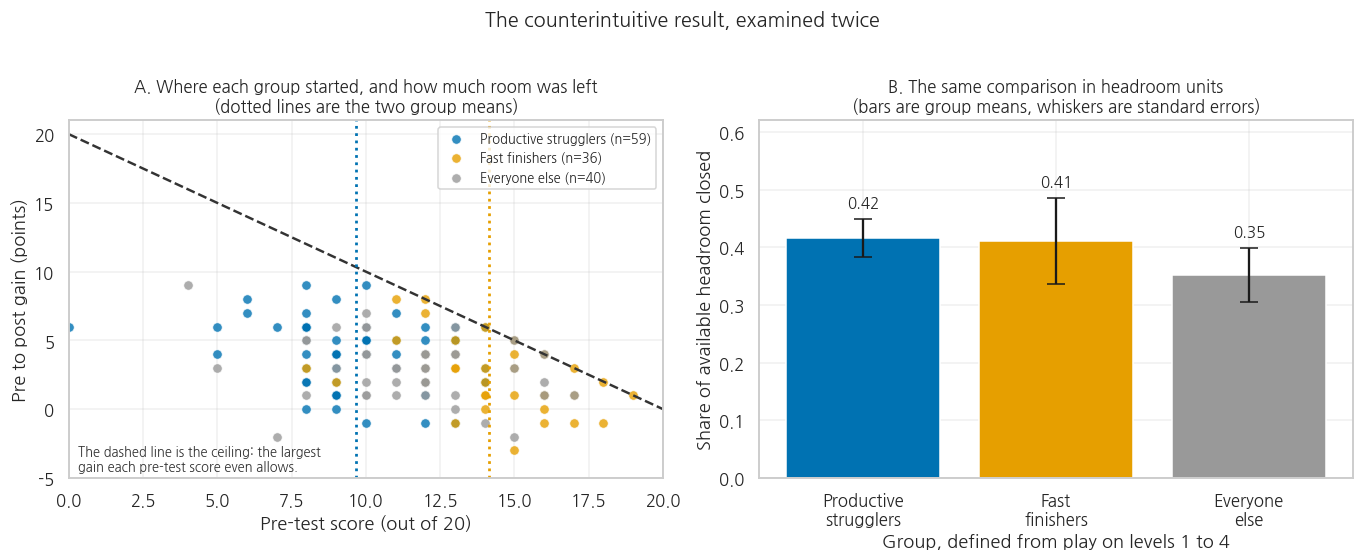

Raw points gained     : strugglers 4.17 vs fast finishers 2.47   (Cohen's d = +0.69, 95% interval +0.26 to +1.11)
Share of headroom used: strugglers 0.416 vs fast finishers 0.411   (Cohen's d = +0.01, 95% interval -0.40 to +0.43)

Mean pre-test score   : strugglers 9.7 vs fast finishers 14.1
Mean post-test score  : strugglers 13.8 vs fast finishers 16.6


In [11]:
eligible['headroom'] = 20 - eligible['pre_score']
eligible['headroom_gain'] = eligible['gain'] / eligible['headroom']

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.9))

# --- Panel A: the ceiling, drawn
ax = axes[0]
for g in GROUP_ORDER:
    sub = eligible[eligible['group'] == g]
    ax.scatter(sub['pre_score'], sub['gain'], s=38, color=GROUP_COLOR[g], alpha=0.8,
               edgecolor='white', linewidth=0.5, label='%s (n=%d)' % (g, len(sub)))
xs = np.arange(0, 20.1, 0.5)
ax.plot(xs, 20 - xs, color=BLACK, linestyle='--', linewidth=1.6)
ax.text(0.3, -4.7, 'The dashed line is the ceiling: the largest\ngain each pre-test score even allows.',
        fontsize=8.5, color=BLACK, ha='left', va='bottom')
for g in ['Productive strugglers', 'Fast finishers']:
    ax.axvline(profile.loc[g, 'pre_score'], color=GROUP_COLOR[g], linestyle=':', linewidth=1.8)
ax.set_xlabel('Pre-test score (out of 20)')
ax.set_ylabel('Pre to post gain (points)')
ax.set_title('A. Where each group started, and how much room was left\n(dotted lines are the two group means)')
ax.set_xlim(0, 20)
ax.set_ylim(-5, 21)
ax.legend(loc='upper right', fontsize=8.5, frameon=True)

# --- Panel B: headroom gain
ax = axes[1]
means = [eligible.loc[eligible['group'] == g, 'headroom_gain'].mean() for g in GROUP_ORDER]
sems = [eligible.loc[eligible['group'] == g, 'headroom_gain'].sem() for g in GROUP_ORDER]
ax.bar(range(3), means, yerr=sems, capsize=6, color=[GROUP_COLOR[g] for g in GROUP_ORDER],
       edgecolor='white')
for i, (m, s) in enumerate(zip(means, sems)):
    ax.text(i, m + s + 0.02, '%.2f' % m, ha='center', fontsize=10)
ax.set_xticks(range(3))
ax.set_xticklabels(['Productive\nstrugglers', 'Fast\nfinishers', 'Everyone\nelse'])
ax.set_ylabel('Share of available headroom closed')
ax.set_xlabel('Group, defined from play on levels 1 to 4')
ax.set_ylim(0, 0.62)
ax.set_title('B. The same comparison in headroom units\n(bars are group means, whiskers are standard errors)')

fig.suptitle('The counterintuitive result, examined twice', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

ps_h = eligible.loc[eligible['group'] == 'Productive strugglers', 'headroom_gain']
ff_h = eligible.loc[eligible['group'] == 'Fast finishers', 'headroom_gain']
print("Raw points gained     : strugglers %.2f vs fast finishers %.2f   "
      "(Cohen's d = %+.2f, 95%% interval %+.2f to %+.2f)"
      % (ps.mean(), ff.mean(), cohens_d(ps, ff), *d_interval(ps, ff)))
print("Share of headroom used: strugglers %.3f vs fast finishers %.3f   "
      "(Cohen's d = %+.2f, 95%% interval %+.2f to %+.2f)"
      % (ps_h.mean(), ff_h.mean(), cohens_d(ps_h, ff_h), *d_interval(ps_h, ff_h)))
print()
print('Mean pre-test score   : strugglers %.1f vs fast finishers %.1f'
      % (profile.loc['Productive strugglers', 'pre_score'], profile.loc['Fast finishers', 'pre_score']))
print('Mean post-test score  : strugglers %.1f vs fast finishers %.1f'
      % (profile.loc['Productive strugglers', 'post_score'], profile.loc['Fast finishers', 'post_score']))

**Interpretation prompt. Sit with the two numbers.**

In raw points the strugglers gain far more, **d = 0.69**, though with an interval from 0.26 to 1.11. In headroom units the difference is **indistinguishable from zero, d = 0.01**, interval -0.40 to 0.43, which rules out a large difference in either direction rather than proving the two groups equal. Same 95 children, same test, same code, two different answers to "who learned more."

1. Which of the two is the right answer? Defend your choice for thirty seconds, then argue the other side for thirty seconds. This is a **measurement** question wearing a learning theory costume, and it is worth arguing about because the two metrics imply different interventions.
2. Here is the sentence most people write after seeing Panel B: "so the productive struggle effect was just a ceiling effect." Name the thing that sentence throws away. Panel A of the previous figure has it.
3. Look at the scatter in Panel A above. There are children at every pre-test score who gained nothing, and a few who lost points. What does the existence of low scorers with low gains do to a claim that struggling is what produced the gains?
4. Suppose the district only had post-test scores, no pre-test. Which of these two findings could they have discovered? What does that tell you about what a game analytics platform should be instrumented to collect?
5. Neither analysis is causal. Write out the confound in the form "children who X were already Y, and Y is what actually produced the gain." Then say what design would settle it, and whether a school would let you run it.

### 4.2 Regression to the mean, which is not the ceiling and is not politeness

Here is a fact about gain scores that has nothing to do with fractions, children, or games.

A pre-test score is a true amount of fraction knowledge **plus measurement error**: twenty items, a
particular Tuesday, a particular night's sleep. Any group selected for a low pre-test score is
therefore partly a group that had a bad morning, and on a second measurement the bad morning does not
repeat. Their scores drift back up toward the middle *whether or not anything happened in between*.
The same argument runs downward for a group selected for a high pre-test score. This is **regression
to the mean**, and it manufactures exactly the pattern we found: the low starters gain, the high
starters do not.

Did we select on the pre-test? Not directly. We selected on **errors in levels 1 to 4**, which is not
the pre-test. But look at what the cell prints: those two things correlate at about -0.60. Selecting
on early errors is most of the way to selecting on the pre-test, so the machinery applies to us.

The ceiling and regression to the mean are genuinely different objects. The ceiling is a property of
a twenty item test with a hard upper edge. Regression to the mean is a property of any measurement
taken twice with noise in it, and it would still be here on a test scored out of a thousand. The
headroom adjustment in 4.1 addresses the first. It does nothing about the second.

The standard tool for the second is to stop analysing gains and instead **model the post-test score
while holding the pre-test constant**, which is an analysis of covariance. The cell fits it.

One honest warning before you read the output. With groups that formed themselves rather than being
randomly assigned, the gain-score analysis and the covariance analysis answer genuinely different
questions and are entitled to disagree. That is a known and long-argued result, not a bug and not a
mistake by whichever one you like less. The point of running the third analysis is not to crown a
winner. It is that you now have to say out loud which question you were asking.

Correlation between errors in levels 1 to 4 and the pre-test score: r = -0.60
Correlation between the pre-test score and the raw gain           : r = -0.41
Test-retest correlation, pre against post, all 200 players        : r = 0.73

The second of those three is the signature of the problem: children who started lower gained
more, across the whole sample, including children in no group at all.

Analysis of covariance:  post_score ~ pre_score + being a productive struggler   (n = 95)
  every extra pre-test point is worth 0.68 post-test points (SE 0.10)
  being a productive struggler is worth +0.25 post-test points (SE 0.66)
  95% interval for that group difference: -1.03 to +1.54 points
  standardized against the residual spread: d = +0.11

Three analyses of the same 95 children, and the third agrees with the second:
  raw points gained          d = +0.69   (95% interval +0.26 to +1.11)
  share of headroom closed   d = +0.01   (95% interval -0.40 to +0.43)
  post-test, pre-test held con

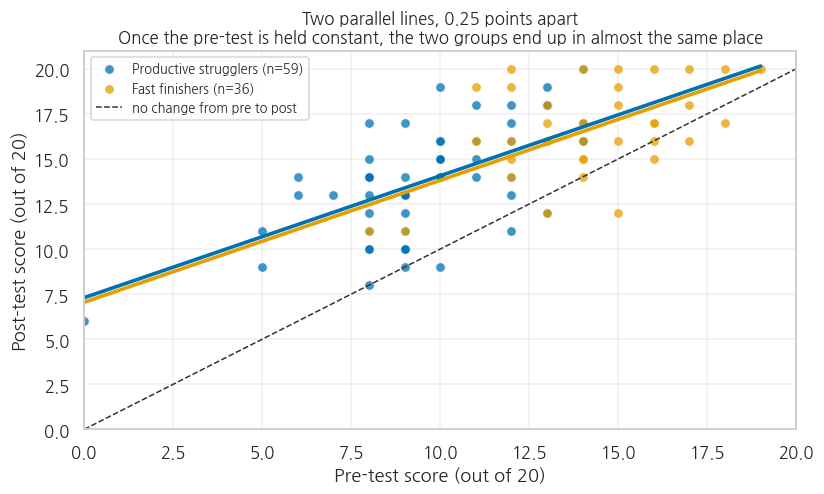

In [12]:
# Do our groups differ on the pre-test, and is our selection variable a proxy for it?
print('Correlation between errors in levels 1 to 4 and the pre-test score: r = %.2f'
      % eligible['errors_1_4'].corr(eligible['pre_score']))
print('Correlation between the pre-test score and the raw gain           : r = %.2f'
      % eligible['pre_score'].corr(eligible['gain']))
print('Test-retest correlation, pre against post, all 200 players        : r = %.2f'
      % players['pre_score'].corr(players['post_score']))
print()
print('The second of those three is the signature of the problem: children who started lower gained')
print('more, across the whole sample, including children in no group at all.')
print()

# --- Analysis of covariance: post-test, holding the pre-test constant.
two = eligible[eligible['group'].isin(['Productive strugglers', 'Fast finishers'])].copy()
two['is_struggler'] = (two['group'] == 'Productive strugglers').astype(int)

X = np.column_stack([np.ones(len(two)), two['pre_score'].to_numpy(), two['is_struggler'].to_numpy()])
y = two['post_score'].to_numpy()
beta, *_ = np.linalg.lstsq(X, y, rcond=None)
resid = y - X @ beta
dof = len(two) - X.shape[1]
sigma2 = (resid ** 2).sum() / dof
se = np.sqrt(np.diag(sigma2 * np.linalg.inv(X.T @ X)))

print('Analysis of covariance:  post_score ~ pre_score + being a productive struggler   (n = %d)' % len(two))
print('  every extra pre-test point is worth %.2f post-test points (SE %.2f)' % (beta[1], se[1]))
print('  being a productive struggler is worth %+.2f post-test points (SE %.2f)' % (beta[2], se[2]))
print('  95%% interval for that group difference: %+.2f to %+.2f points'
      % (beta[2] - 1.96 * se[2], beta[2] + 1.96 * se[2]))
print('  standardized against the residual spread: d = %+.2f' % (beta[2] / np.sqrt(sigma2)))
print()
print('Three analyses of the same 95 children, and the third agrees with the second:')
print('  raw points gained          d = %+.2f   (95%% interval %+.2f to %+.2f)'
      % (cohens_d(ps, ff), *d_interval(ps, ff)))
print('  share of headroom closed   d = %+.2f   (95%% interval %+.2f to %+.2f)'
      % (cohens_d(ps_h, ff_h), *d_interval(ps_h, ff_h)))
print('  post-test, pre-test held constant  d = %+.2f' % (beta[2] / np.sqrt(sigma2)))

fig, ax = plt.subplots(figsize=(7.6, 4.6))
xs = np.linspace(eligible['pre_score'].min(), eligible['pre_score'].max(), 50)
for g, is_s in [('Productive strugglers', 1), ('Fast finishers', 0)]:
    sub = two[two['group'] == g]
    ax.scatter(sub['pre_score'], sub['post_score'], s=38, color=GROUP_COLOR[g], alpha=0.75,
               edgecolor='white', linewidth=0.5, label='%s (n=%d)' % (g, len(sub)))
    ax.plot(xs, beta[0] + beta[1] * xs + beta[2] * is_s, color=GROUP_COLOR[g], linewidth=2.4)
ax.plot([0, 20], [0, 20], color=BLACK, linestyle='--', linewidth=1,
        label='no change from pre to post')
ax.set_xlabel('Pre-test score (out of 20)')
ax.set_ylabel('Post-test score (out of 20)')
ax.set_xlim(0, 20)
ax.set_ylim(0, 21)
ax.set_title('Two parallel lines, %.2f points apart\nOnce the pre-test is held constant, the two '
             'groups end up in almost the same place' % beta[2])
ax.legend(loc='upper left', fontsize=8.5, frameon=True)
plt.tight_layout()
plt.show()

**Interpretation prompt.**

1. The gap between the two fitted lines is a fraction of a point, with an interval that comfortably
   contains zero. Write the one sentence you would now put in an abstract, and make sure it is a
   sentence about **measurement decisions** rather than about children.
2. Notice what did *not* happen here. Nothing in this section says the productive strugglers did
   badly, and nothing says the fast finishers were lazy or coasting. The fast finishers arrived
   knowing more fractions and left knowing more fractions, and closed the same share of the distance
   available to them. Both descriptions are of play patterns, not of people. Write the sentence a
   newsletter would print about the fast finishers after reading only section 4, and then write the
   correction.
3. Section 4 opened by asking which of two children learned more fractions. Having now run three
   analyses, say precisely what this study can and cannot answer, and notice that "we cannot tell
   from these data which child learned more" is a complete and respectable answer.
4. Regression to the mean would still be here if the test had 1,000 items and no ceiling at all. The
   headroom adjustment would not. Explain that difference to a colleague in two sentences, because
   people conflate them constantly and the conflation is how a real finding gets thrown away.

### ✏️ Your turn 3

How much of that finding is the world, and how much is the four numbers we picked? Move them. The
cell reports the raw-points *d* and the headroom *d*; keep section 4.2 in view while you read them,
because neither of those two removes regression to the mean.

All four have working defaults that reproduce the result above, so the cell runs untouched. Then try, one at a time:

- `MIN_LEVEL_REACHED = 8` (compare only children who finished the whole game)
- `ERROR_HIGH_PCTL = 0.75` and `ERROR_LOW_PCTL = 0.25` (sharper, smaller groups)
- `MIN_RETRIES = 2` (require real persistence, not one stumble)

In [13]:
# ✏️ TODO: change any of these four and rerun. The defaults reproduce section 4.
MIN_LEVEL_REACHED = 4      # a player must have reached at least this level to be compared
ERROR_HIGH_PCTL   = 0.50   # strugglers make more errors than this percentile
ERROR_LOW_PCTL    = 0.33   # fast finishers make errors at or below this percentile
MIN_RETRIES       = 1      # strugglers must have retried at least this many times

sub = play[play['max_level'] >= MIN_LEVEL_REACHED].copy()
hi = sub['errors_1_4'].quantile(ERROR_HIGH_PCTL)
lo = sub['errors_1_4'].quantile(ERROR_LOW_PCTL)

sub['group'] = np.where((sub['errors_1_4'] > hi) & (sub['retries_1_4'] >= MIN_RETRIES),
                        'Productive strugglers',
                        np.where((sub['errors_1_4'] <= lo) & (sub['retries_1_4'] == 0),
                                 'Fast finishers', 'Everyone else'))
sub['headroom_gain'] = sub['gain'] / (20 - sub['pre_score'])

a = sub.loc[sub['group'] == 'Productive strugglers']
b = sub.loc[sub['group'] == 'Fast finishers']

print('Eligible players (reached level %d or deeper): %d' % (MIN_LEVEL_REACHED, len(sub)))
print('Error thresholds: strugglers above %.1f, fast finishers at or below %.1f' % (hi, lo))
print()
if len(a) < 5 or len(b) < 5:
    print('One of the groups has fewer than 5 players (%d and %d). Loosen a threshold and rerun.'
          % (len(a), len(b)))
else:
    print('%-22s n=%3d  pre=%.1f  post=%.1f  gain=%.2f  headroom gain=%.3f'
          % ('Productive strugglers', len(a), a.pre_score.mean(), a.post_score.mean(),
             a.gain.mean(), a.headroom_gain.mean()))
    print('%-22s n=%3d  pre=%.1f  post=%.1f  gain=%.2f  headroom gain=%.3f'
          % ('Fast finishers', len(b), b.pre_score.mean(), b.post_score.mean(),
             b.gain.mean(), b.headroom_gain.mean()))
    print()
    print("Cohen's d, raw points   : %+.2f" % cohens_d(a.gain, b.gain))
    print("Cohen's d, headroom gain: %+.2f" % cohens_d(a.headroom_gain, b.headroom_gain))

Eligible players (reached level 4 or deeper): 135
Error thresholds: strugglers above 16.0, fast finishers at or below 13.0

Productive strugglers  n= 59  pre=9.7  post=13.8  gain=4.17  headroom gain=0.416
Fast finishers         n= 36  pre=14.1  post=16.6  gain=2.47  headroom gain=0.411

Cohen's d, raw points   : +0.69
Cohen's d, headroom gain: +0.01


**Interpretation prompt.** How far did the raw-points `d` move when you changed the settings? How far did the headroom `d` move? A finding that survives every setting you tried is worth reporting. A finding that only appears at one combination of four numbers is worth reporting differently, and you should say which one you have.

## 📊 5. Emotion pings: reading a stream instead of a table

Now `game_emotion.csv`. Each row is one moment when the game interrupted a child and asked how they were feeling, and the child picked one of four words plus an intensity from 1 to 5. There are 2,175 of these across 200 players, roughly 11 per child.

D'Mello and Jensen make two arguments that shape everything below. First, **confusion is not the enemy**. Confusion is what it feels like to hit the edge of what you know, and a learning environment where nobody is ever confused is one where nobody is learning anything new. Second, the affective states that matter for learning are **dynamic**: what predicts outcomes is not how often a state occurs but where it goes next. Confusion that gets resolved is a different event from confusion that does not.

So we do this in three moves: what gets reported and where, what one child's stream actually looks like, and then the sequence question.

### 5.1 What children report, level by level

How often each emotion is reported overall:
emotion
interest       983
confusion      739
frustration    336
boredom        117

Percent of pings at each level (rows sum to 100):
emotion  interest  confusion  frustration  boredom
level                                             
1            40.8       38.7         13.1      7.4
2            50.1       31.2         13.0      5.7
3            48.7       31.8         12.2      7.4
4            27.0       46.6         24.6      1.8
5            52.3       30.0         12.3      5.5
6            50.7       31.1         13.9      4.3
7            50.0       24.7         21.6      3.7
8            48.3       29.8         17.2      4.6

Raw ping counts at each level:
emotion  interest  confusion  frustration  boredom
level                                             
1             177        168           57       32
2             177        110           46       20
3             164        107           41       25
4              76       

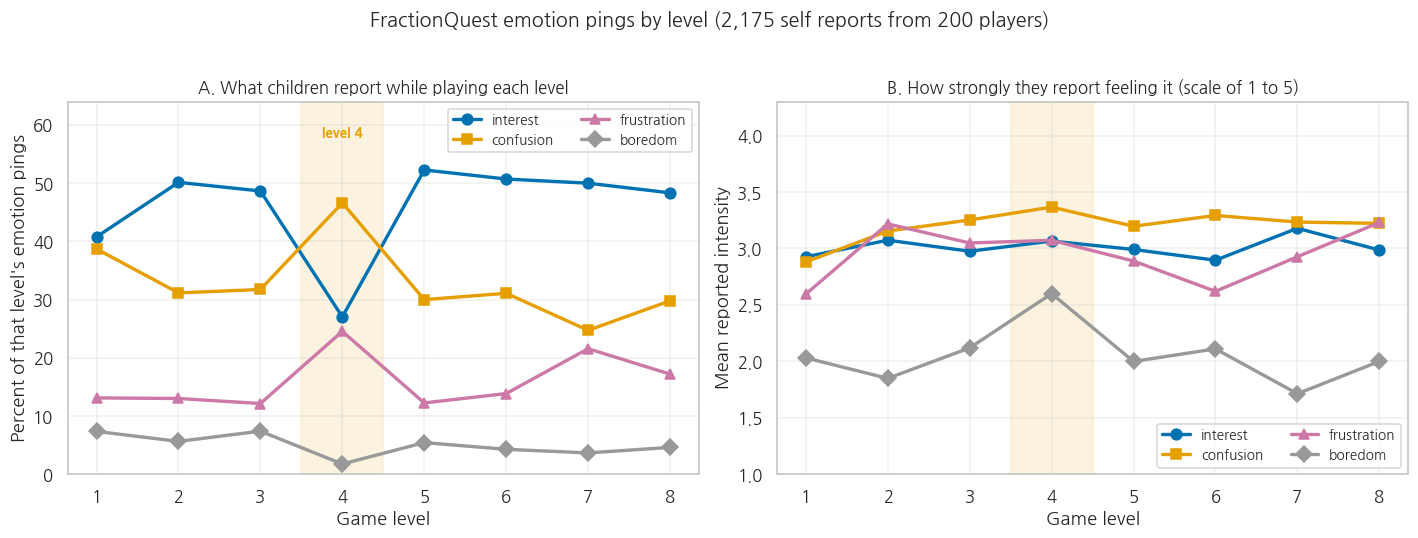

In [14]:
EMO_ORDER = ['interest', 'confusion', 'frustration', 'boredom']
EMO_COLOR = {'interest': BLUE, 'confusion': ORANGE, 'frustration': PINK, 'boredom': GRAY}
EMO_MARKER = {'interest': 'o', 'confusion': 's', 'frustration': '^', 'boredom': 'D'}

print('How often each emotion is reported overall:')
print(emotion['emotion'].value_counts().reindex(EMO_ORDER).to_string())
print()

share = pd.crosstab(emotion['level'], emotion['emotion'], normalize='index')[EMO_ORDER] * 100
counts = pd.crosstab(emotion['level'], emotion['emotion'])[EMO_ORDER]
print('Percent of pings at each level (rows sum to 100):')
print(share.round(1).to_string())
print()
print('Raw ping counts at each level:')
print(counts.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.7))

ax = axes[0]
for e in EMO_ORDER:
    ax.plot(share.index, share[e], marker=EMO_MARKER[e], markersize=7, linewidth=2.2,
            color=EMO_COLOR[e], label=e)
ax.axvspan(3.5, 4.5, color=ORANGE, alpha=0.12, zorder=0)
ax.text(4, 58, 'level 4', ha='center', fontsize=9, color=ORANGE, weight='bold')
ax.set_title('A. What children report while playing each level')
ax.set_xlabel('Game level')
ax.set_ylabel('Percent of that level\'s emotion pings')
ax.set_xticks(range(1, 9))
ax.set_ylim(0, 64)
ax.legend(loc='upper right', fontsize=9, ncol=2, frameon=True)

ax = axes[1]
intensity = emotion.pivot_table(index='level', columns='emotion', values='intensity',
                                aggfunc='mean')[EMO_ORDER]
for e in EMO_ORDER:
    ax.plot(intensity.index, intensity[e], marker=EMO_MARKER[e], markersize=7, linewidth=2.2,
            color=EMO_COLOR[e], label=e)
ax.axvspan(3.5, 4.5, color=ORANGE, alpha=0.12, zorder=0)
ax.set_title('B. How strongly they report feeling it (scale of 1 to 5)')
ax.set_xlabel('Game level')
ax.set_ylabel('Mean reported intensity')
ax.set_xticks(range(1, 9))
ax.set_ylim(1, 4.3)
ax.legend(loc='lower right', fontsize=9, ncol=2, frameon=True)

fig.suptitle('FractionQuest emotion pings by level (2,175 self reports from 200 players)',
             fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

**Interpretation prompt.** At level 4, confusion is 47 percent of pings and frustration is 25 percent, while interest collapses from about 49 percent at level 3 to 27 percent. Panel B shows intensity barely moves. The cliff you found in the telemetry has an affective signature, and it is a signature of *how many* children report confusion, not of how hard they report feeling it.

1. Panel A and the level-4 telemetry are two **different kinds** of instrument pointing at the same level: one records what a child clicked when asked, the other records what the child's attempts did. They are not statistically independent, since one hard level drives both, but they fail in different ways, and that is what makes their agreement worth something. Say why, using the phrases "self report" and "behavioral trace."
2. Boredom is rarest at level 4, its lowest point in the game. Give two readings of that fact, and make both of them readings **about the level**: one in which level 4 is doing something right, and one in which it is doing something wrong. Resist the version where the fact turns out to be about the children.
3. These are the pings of players *who are still playing*. What would the level 4 bar look like if the children who quit at level 4 had been asked one more time? Which direction does the missingness push your estimate?
4. D'Mello and Jensen would say Panel A is not a picture of emotion. It is a picture of what children clicked when a game asked. Name two reasons an eleven year old might report "interest" while feeling something else.

### 5.2 One child at a time

A percentage per level is an average over hundreds of children who never had the same experience. The unit that actually carries D'Mello and Jensen's argument is the **stream**: one player's emotions, in order, as they moved through the game.

Below are six real players from the dataset, two from each of the three patterns we are about to define. The gray band shows how far each child got before they stopped playing, and the black bar marks their last level. Each marker is one ping, positioned at the level where it happened, with shape and color giving the emotion and size giving the intensity.

Read them like six short stories, not like a chart.

Example players shown below: ['P001', 'P005', 'P003', 'P006', 'P024', 'P077']


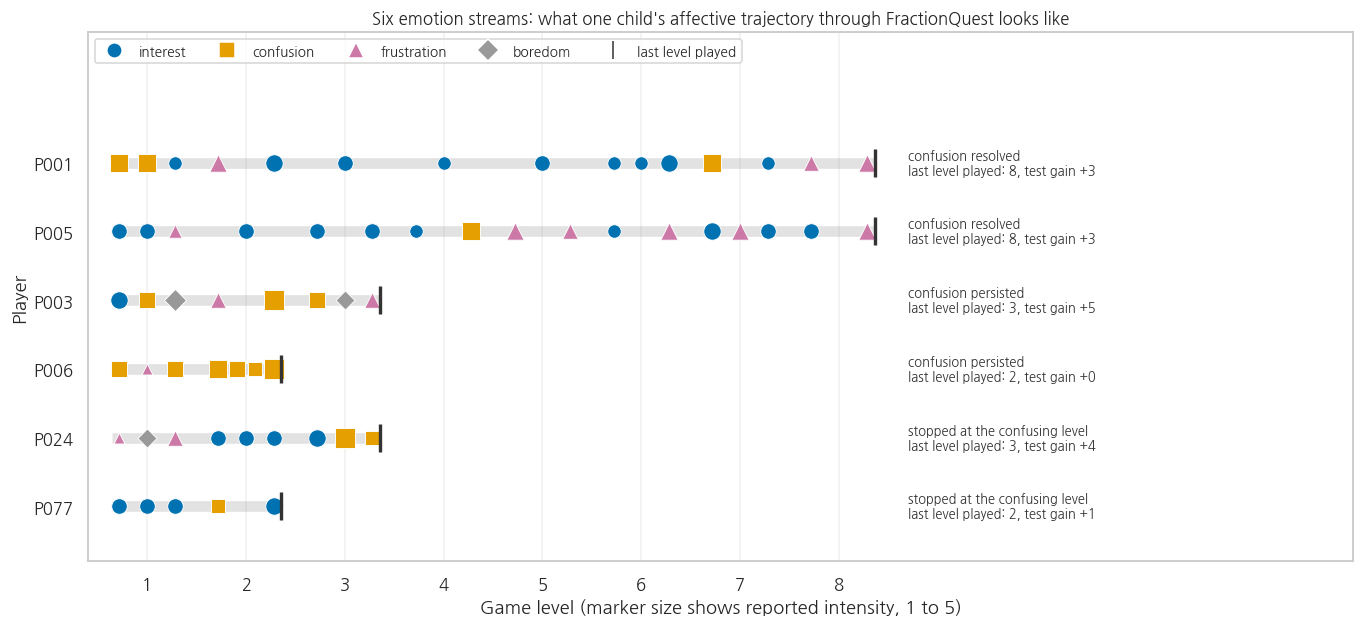

In [15]:
# --- Classify every player's confusion trajectory.
confusion = emotion[emotion['emotion'] == 'confusion']
first_confusion = confusion.groupby('player_id')['level'].min()
confusion_levels = confusion.groupby('player_id')['level'].apply(set).to_dict()
deepest_level = telemetry.groupby('player_id')['level'].max()

RESOLUTION_WINDOW = 2      # "resolved within two levels"


def confusion_pattern(player_id, window=RESOLUTION_WINDOW):
    if player_id not in first_confusion.index:
        return 'never reported confusion'
    start = int(first_confusion[player_id])
    reported_at = confusion_levels[player_id]
    played_after = [lv for lv in range(start + 1, start + 1 + window)
                    if lv <= deepest_level[player_id]]
    if not played_after:
        return 'stopped at the confusing level'
    if any(lv in reported_at for lv in played_after):
        return 'confusion persisted'
    return 'confusion resolved'


players_emotion = players.copy()
players_emotion['gain'] = players_emotion['post_score'] - players_emotion['pre_score']
players_emotion['max_level'] = players_emotion['player_id'].map(deepest_level)
players_emotion['pattern'] = players_emotion['player_id'].apply(confusion_pattern)
players_emotion['quit_before_level_8'] = (players_emotion['max_level'] < 8).astype(int)
players_emotion['n_pings'] = players_emotion['player_id'].map(emotion.groupby('player_id').size())

PATTERNS = ['confusion resolved', 'confusion persisted', 'stopped at the confusing level']

# --- Pick two example players per pattern, deterministically (lowest player IDs with enough pings).
examples = []
for pat in PATTERNS:
    pool = (players_emotion[(players_emotion['pattern'] == pat) & (players_emotion['n_pings'] >= 5)]
            .sort_values('player_id'))
    examples += list(pool['player_id'].head(2))
print('Example players shown below:', examples)

fig, ax = plt.subplots(figsize=(12.5, 5.8))
for row, pid in enumerate(reversed(examples)):
    y = row
    stop = int(deepest_level[pid])
    # The band runs a little past the last level so that pings drawn at that level stay inside it.
    ax.plot([0.65, stop + 0.36], [y, y], color=GRAY, linewidth=7, alpha=0.28,
            solid_capstyle='butt', zorder=1)
    ax.scatter([stop + 0.36], [y], marker='|', s=320, color=BLACK, linewidth=2.2, zorder=4)
    pings = emotion[emotion['player_id'] == pid].sort_values('timestamp')
    for lv, chunk in pings.groupby('level'):
        k = len(chunk)
        offsets = np.linspace(-0.28, 0.28, k) if k > 1 else np.array([0.0])
        for off, (_, p) in zip(offsets, chunk.iterrows()):
            ax.scatter(lv + off, y, marker=EMO_MARKER[p['emotion']],
                       s=26 + 26 * p['intensity'], color=EMO_COLOR[p['emotion']],
                       edgecolor='white', linewidth=0.6, zorder=3)
    pat = players_emotion.loc[players_emotion['player_id'] == pid, 'pattern'].iloc[0]
    gain = int(players_emotion.loc[players_emotion['player_id'] == pid, 'gain'].iloc[0])
    ax.text(8.7, y, '%s\nlast level played: %d, test gain %+d' % (pat, stop, gain),
            fontsize=8.5, va='center', color=BLACK)

ax.set_yticks(range(len(examples)))
ax.set_yticklabels(list(reversed(examples)))
ax.set_ylim(-0.8, len(examples) + 0.9)
ax.set_xlim(0.4, 13.2)
ax.set_xticks(range(1, 9))
ax.set_xlabel('Game level (marker size shows reported intensity, 1 to 5)')
ax.set_ylabel('Player')
ax.set_title("Six emotion streams: what one child's affective trajectory through FractionQuest looks like")
handles = [plt.Line2D([], [], marker=EMO_MARKER[e], color='white', markerfacecolor=EMO_COLOR[e],
                      markeredgecolor='white', markersize=10, linestyle='None', label=e)
           for e in EMO_ORDER]
handles.append(plt.Line2D([], [], marker='|', color=BLACK, linestyle='None', markersize=12,
                          label='last level played'))
ax.legend(handles=handles, loc='upper left', ncol=5, fontsize=9, frameon=True)
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

**Interpretation prompt.** Find the rows that end early. For those children, the last recorded feeling is the last thing the game ever knew about them.

1. Pick any one row and narrate it in three sentences, as if you were the teacher of that child. Then underline every word in your narration that the data does not actually support.
2. Two children can have the same *count* of confusion pings and completely different rows. Point at two and say what a frequency table would have lost.
3. A real product would show a teacher a dashboard tile that reads "3 students frustrated today." Looking at these six rows, what has that tile deleted?

### 5.3 The sequence question: does the confusion go away?

Now the definition that makes this a sequence analysis rather than a tally. For every child who ever reported confusion, find the **first** level where they reported it, then look at the **next two levels they actually played**.

> **Confusion resolved**: they played on, and reported no further confusion in the next two levels.
>
> **Confusion persisted**: they reported confusion again within those two levels.
>
> **Stopped at the confusing level**: there were no next two levels. They never played again.

That third group exists because of a decision we could have made silently and should not. A child who quits at their first confusing level has no observable resolution, and filing them under "resolved" (they never reported confusion again, technically) would be one of the most flattering bugs in learning analytics. Keep them visible.

The same bug has a milder version that is easy to miss. A child who played exactly **one** more level and reported no confusion there gets filed as "resolved" on half a window of evidence, and a half-length window is a smaller chance to catch a repeat. The cell counts those cases and recomputes the comparison without them, so you can see how much the classification rests on them rather than taking our word for it.

We then ask two things of the three groups: how much they gained on the fractions test, and how often they quit before level 8.

Players who ever reported confusion: 186 out of 200

Confusion trajectories, with a resolution window of 2 levels:
                                 n  first_confusion_level  pre_score  post_score   gain  deepest_level  quit_rate
pattern                                                                                                          
confusion resolved              73                  1.753     11.630      15.411  3.781          6.890      0.342
confusion persisted             90                  1.611     10.167      12.878  2.711          5.311      0.633
stopped at the confusing level  23                  1.739     10.870      13.348  2.478          1.739      1.000


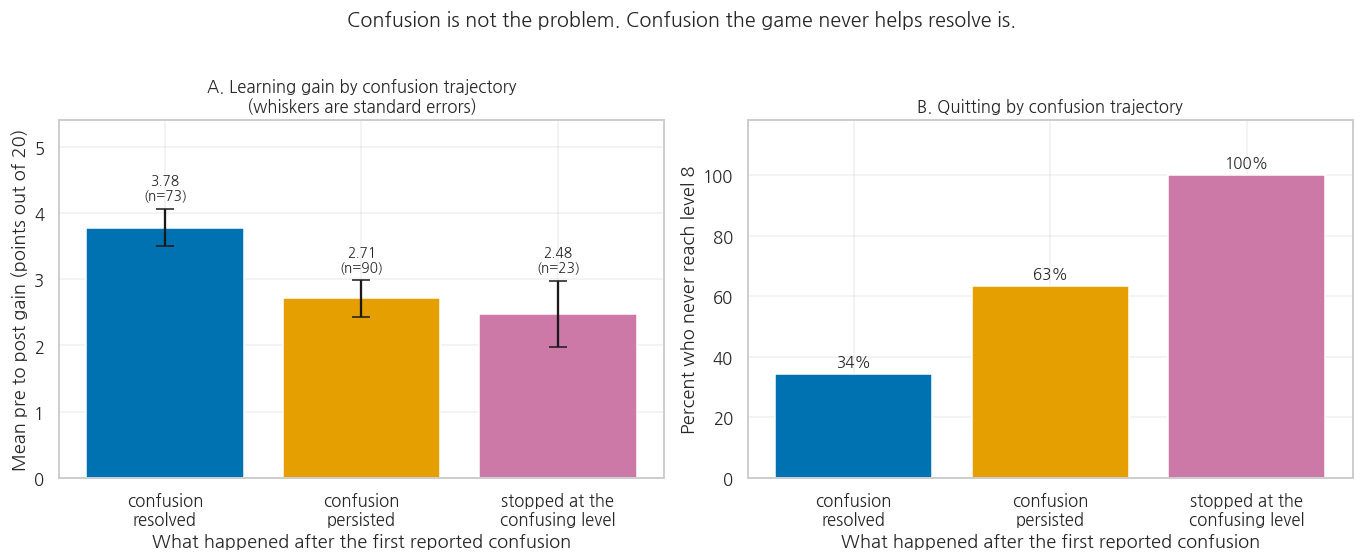


Cohen's d, resolved vs persisted           : 0.42  (95% interval 0.11 to 0.74)
Cohen's d, resolved vs everyone unresolved : 0.45  (95% interval 0.15 to 0.74)
Quit rate, resolved vs everyone unresolved : 34% vs 71%

Classification check: 2 of the 73 children filed as "confusion resolved" were seen for fewer
than the full 2 levels, so their label rests on less evidence than the others.
Dropping them: mean gain 3.76 (n=71) against 3.78 (n=73) with them in, and the comparison
against everyone unresolved moves from d = 0.45 to d = 0.44. The label survives the check.

Levels played after the first reported confusion, by group (median):
pattern
confusion resolved                6.0
confusion persisted               3.0
stopped at the confusing level    0.0
Both observed groups had room to report confusion again, so the gap between them is not
simply a gap in how much game was left to report anything in.

For contrast, the 14 players who never reported confusion at all gained 2.14 on average.

In [16]:
confused_players = players_emotion[players_emotion['pattern'] != 'never reported confusion'].copy()
print('Players who ever reported confusion: %d out of %d' % (len(confused_players), len(players_emotion)))
print()

pattern_table = confused_players.groupby('pattern').agg(
    n=('player_id', 'size'),
    first_confusion_level=('player_id', lambda s: first_confusion[s].mean()),
    pre_score=('pre_score', 'mean'),
    post_score=('post_score', 'mean'),
    gain=('gain', 'mean'),
    deepest_level=('max_level', 'mean'),
    quit_rate=('quit_before_level_8', 'mean'),
).loc[PATTERNS]
print('Confusion trajectories, with a resolution window of %d levels:' % RESOLUTION_WINDOW)
print(pattern_table.round(3).to_string())

PATTERN_COLOR = {'confusion resolved': BLUE,
                 'confusion persisted': ORANGE,
                 'stopped at the confusing level': PINK}
labels = ['confusion\nresolved', 'confusion\npersisted', 'stopped at the\nconfusing level']

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.9))

ax = axes[0]
gains = [confused_players.loc[confused_players['pattern'] == p, 'gain'] for p in PATTERNS]
ax.bar(range(3), [g.mean() for g in gains], yerr=[g.sem() for g in gains], capsize=6,
       color=[PATTERN_COLOR[p] for p in PATTERNS], edgecolor='white')
for i, g in enumerate(gains):
    ax.text(i, g.mean() + g.sem() + 0.14, '%.2f\n(n=%d)' % (g.mean(), len(g)),
            ha='center', fontsize=9)
ax.set_xticks(range(3))
ax.set_xticklabels(labels)
ax.set_ylabel('Mean pre to post gain (points out of 20)')
ax.set_xlabel('What happened after the first reported confusion')
ax.set_ylim(0, 5.4)
ax.set_title('A. Learning gain by confusion trajectory\n(whiskers are standard errors)')

ax = axes[1]
quits = [100 * confused_players.loc[confused_players['pattern'] == p, 'quit_before_level_8'].mean()
         for p in PATTERNS]
ax.bar(range(3), quits, color=[PATTERN_COLOR[p] for p in PATTERNS], edgecolor='white')
for i, q in enumerate(quits):
    ax.text(i, q + 2.5, '%.0f%%' % q, ha='center', fontsize=10)
ax.set_xticks(range(3))
ax.set_xticklabels(labels)
ax.set_ylabel('Percent who never reach level 8')
ax.set_xlabel('What happened after the first reported confusion')
ax.set_ylim(0, 118)
ax.set_title('B. Quitting by confusion trajectory')

fig.suptitle('Confusion is not the problem. Confusion the game never helps resolve is.',
             fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

res = confused_players.loc[confused_players['pattern'] == 'confusion resolved', 'gain']
per = confused_players.loc[confused_players['pattern'] == 'confusion persisted', 'gain']
unresolved = confused_players.loc[confused_players['pattern'] != 'confusion resolved', 'gain']
print()
print("Cohen's d, resolved vs persisted           : %.2f  (95%% interval %.2f to %.2f)"
      % (cohens_d(res, per), *d_interval(res, per)))
print("Cohen's d, resolved vs everyone unresolved : %.2f  (95%% interval %.2f to %.2f)"
      % (cohens_d(res, unresolved), *d_interval(res, unresolved)))
print('Quit rate, resolved vs everyone unresolved : %.0f%% vs %.0f%%'
      % (100 * confused_players.loc[confused_players['pattern'] == 'confusion resolved',
                                    'quit_before_level_8'].mean(),
         100 * confused_players.loc[confused_players['pattern'] != 'confusion resolved',
                                    'quit_before_level_8'].mean()))
# --- Was "resolved" bought on a half-length window? Count the cases and drop them.
players_emotion['window_seen'] = players_emotion['player_id'].apply(
    lambda p: 0 if p not in first_confusion.index
    else int(min(deepest_level[p], int(first_confusion[p]) + RESOLUTION_WINDOW) - int(first_confusion[p])))
short = ((players_emotion['pattern'] == 'confusion resolved') &
         (players_emotion['window_seen'] < RESOLUTION_WINDOW))
print()
print('Classification check: %d of the %d children filed as "confusion resolved" were seen for fewer'
      % (int(short.sum()), int((players_emotion['pattern'] == 'confusion resolved').sum())))
print('than the full %d levels, so their label rests on less evidence than the others.'
      % RESOLUTION_WINDOW)
full_res = players_emotion.loc[(players_emotion['pattern'] == 'confusion resolved') & ~short, 'gain']
print('Dropping them: mean gain %.2f (n=%d) against %.2f (n=%d) with them in, and the comparison'
      % (full_res.mean(), len(full_res), res.mean(), len(res)))
print("against everyone unresolved moves from d = %.2f to d = %.2f. The label survives the check."
      % (cohens_d(res, unresolved), cohens_d(full_res, unresolved)))

# --- How much game did each group have left after their first confusion?
after = confused_players.assign(levels_after=[
    int(deepest_level[p] - first_confusion[p]) for p in confused_players['player_id']])
print()
print('Levels played after the first reported confusion, by group (median):')
print(after.groupby('pattern')['levels_after'].median().loc[PATTERNS].to_string())
print('Both observed groups had room to report confusion again, so the gap between them is not')
print('simply a gap in how much game was left to report anything in.')

never = players_emotion.loc[players_emotion['pattern'] == 'never reported confusion']
print()
print('For contrast, the %d players who never reported confusion at all gained %.2f on average.'
      % (len(never), never['gain'].mean()))

**Interpretation prompt.** Children whose confusion cleared within two levels gained **3.78 points**. Children whose confusion came back gained **2.71**. Children who quit at the confusing level gained **2.48**. The standardized difference between resolved confusion and everything else is about **d = 0.45**, and the quit rate is 34 percent against 71 percent.

1. Write the headline. Then write the version of the headline that a game designer could build a feature from, and say what that feature would do. Notice that the second headline is about the game and the first one is probably about the children.
2. Panel B's third bar is 100 percent because the group was **defined** by stopping. Name the circularity out loud. Then say which parts of the figure are *not* circular, and what those parts are worth.
3. The comparison between the first two bars is not circular, and it is still not causal. Both "reported confusion again" and "stopped playing" are downstream of how the game was going for that child, so a common cause could produce both without confusion causing anything. Write the confound as one sentence of the form "children whose confusion persisted were already X, and X is what produced both the repeat report and the quitting," then say what X would have to be and whether this file contains it.
4. The resolved group also started higher on the pre-test, though by 1.3 points rather than the 4.5 that separated the groups in section 4. Apply both of the section 4 moves: does this finding survive a headroom adjustment, and how worried should you be about regression to the mean given a gap that size? Say what you expect, then check it in Solution 4 of the appendix.
5. Now the design question the week turns on. Imagine a feature that detects unresolved confusion and intervenes. What does it do: offer a hint, drop the difficulty, call a teacher over, or say something encouraging? Pick one, and say what it teaches an eleven year old about what to do when they are confused.
6. And the counterweight. If confusion is where learning happens, a system that eliminates confusion has eliminated something valuable. Where exactly is the line between supporting a child and rescuing them out of the learning? Bring an answer to the discussion block.

### ✏️ Your turn 4

"Within two levels" was our decision. It is the entire operational definition of "resolved," and nothing in the data suggested it.

`YOUR_WINDOW` is set to 2, which reproduces section 5.3. Try 1 (strict: resolved means the very next level is clear) and 3 (generous). Watch the group sizes move, and watch what happens to the gap.

Resolution window = 2 level(s) after the first reported confusion
                                 n   gain  pre_score  quit_rate
pattern                                                        
confusion resolved              73  3.781     11.630      0.342
confusion persisted             90  2.711     10.167      0.633
stopped at the confusing level  23  2.478     10.870      1.000

Cohen's d, resolved vs everyone else: 0.45


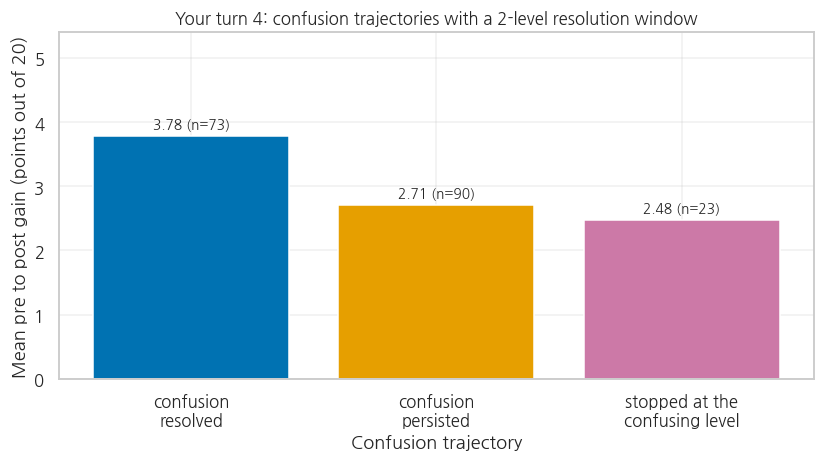

In [17]:
# ✏️ TODO: change the window and rerun. 1 is strict, 3 is generous.
YOUR_WINDOW = 2            # working default: the notebook runs as is

tmp = players_emotion.copy()
tmp['pattern'] = tmp['player_id'].apply(lambda p: confusion_pattern(p, window=YOUR_WINDOW))
tmp = tmp[tmp['pattern'] != 'never reported confusion']

summary = tmp.groupby('pattern').agg(
    n=('player_id', 'size'),
    gain=('gain', 'mean'),
    pre_score=('pre_score', 'mean'),
    quit_rate=('quit_before_level_8', 'mean'),
).reindex(PATTERNS)

print('Resolution window = %d level(s) after the first reported confusion' % YOUR_WINDOW)
print(summary.round(3).to_string())

r = tmp.loc[tmp['pattern'] == 'confusion resolved', 'gain']
o = tmp.loc[tmp['pattern'] != 'confusion resolved', 'gain']
print()
print("Cohen's d, resolved vs everyone else: %.2f" % cohens_d(r, o))

fig, ax = plt.subplots(figsize=(7.6, 4.3))
vals = summary['gain'].values
ax.bar(range(3), vals, color=[PATTERN_COLOR[p] for p in PATTERNS], edgecolor='white')
for i, (v, n) in enumerate(zip(vals, summary['n'].values)):
    ax.text(i, v + 0.12, '%.2f (n=%d)' % (v, n), ha='center', fontsize=9)
ax.set_xticks(range(3))
ax.set_xticklabels(labels)
ax.set_ylabel('Mean pre to post gain (points out of 20)')
ax.set_xlabel('Confusion trajectory')
ax.set_ylim(0, 5.4)
ax.set_title('Your turn 4: confusion trajectories with a %d-level resolution window' % YOUR_WINDOW)
plt.tight_layout()
plt.show()

**Interpretation prompt.** Which window gives the largest gap, and which gives the most balanced group sizes? Those are usually not the same window. Write one sentence you would put in a methods section defending the window you would actually use, and notice that "it gave the biggest effect" is not that sentence.

## 💬 Reflection

Bring written answers to at least **three** of these, including the last one. They are the spine of tonight's discussion block.

**On Reardon, Kumar, and Revelle (2022), "Game learning analytics."**
They argue that games give learning analytics something a course platform cannot: dense, repeated, tightly specified attempts at a known skill, with an outcome the designer chose in advance. Today you had all of that and the analysis still nearly went wrong three separate times (the pooled learning curve, the raw gain comparison, the children who quit while confused). Pick the failure you find most instructive and say what it implies about the claim that finer grained data produces better inferences.

**On D'Mello and Jensen (2022), "Emotional learning analytics."**
Their central move is treating affect as dynamic rather than static: confusion is not a trait a child has, it is a state that goes somewhere. Section 5.3 operationalized "goes somewhere" as a two level window. Name the largest thing that operationalization gets wrong about a real child's experience of being confused, and say whether more emotion pings would fix it or whether the problem is of a different kind.

**On Kim, Knowles, Scianna, Lin, and Ruiperez-Valiente (2023), "Learning analytics application to examine validity and generalizability of game-based assessment for spatial reasoning."**
They ask whether what a game measures is what it claims to measure, and whether it holds up beyond the sample it was built on. FractionQuest's post-test is a 20 item paper test, not the game. Would you rather assess these children with the test or with the telemetry? Argue one side properly, including what you give up.

**Across the readings, on measurement.**
You produced three defensible answers to "who learned more" from the same 95 children: d = 0.69 in raw points, d = 0.01 in headroom units, and a covariance-adjusted difference of a quarter of a point with an interval straddling zero. None of the three is a mistake, and the second and third are answers to different questions that happen to agree. Write the paragraph you would put in a results section that reports all three without weaselling, say which one goes in the abstract, and say what you would have written if you had only run the first.

**The one everybody answers: these learners are children.**
Take one design proposal you have already made this semester (your Week 4 dashboard, your Week 3 model redesign, your Week 9 collaboration analytics, or the seed of your course research project) and rewrite its **user** as an eleven year old and its **audience** as that child's teacher, school, and family.

- What in your proposal stops being defensible?
- Who consents, and what were they actually told?
- Emotion self reports are the most intimate data in this course so far. Would you collect them from a child? Under what conditions, retained for how long, visible to whom?
- Your proposal presumably had an intervention. What does that intervention teach a child about themselves? A flag that says "struggling" is also a message.
- Finally, the hard one: is there a version of your proposal where the child is a **user** rather than a **subject**? Week 11 is about co-design, and this is the bridge to it.

### A question for our guest

Chaewon Kim, Florida State University, joins us this week. [Bio: confirm with speaker]

Come with a real question, and the strongest ones come from something you actually just did. For example, the entire productive struggle finding in section 4 flipped depending on whether gains were measured in raw points or as a share of headroom, and both are standard practice. A question worth asking:

> "When you evaluate a game as a learning environment, what do you use as the outcome, and how do you keep a ceiling effect in the pre-test from deciding your answer for you?"

Or, on the emotional side:

> "Given that in-game affect measures are self reports from children, what have you found children are actually reporting when they click 'interest', and how much would you trust it as a signal to act on?"

## ✅ Before you leave today

**This notebook is not a Canvas submission.** Week 10 is not a mini project (those were weeks 4, 5, 6, and 8). This lab is a launch: we start it together in the studio block and you finish it on your own time.

**What *is* due this week, separately from this notebook:**

- [ ] **Course Research Project Literature Review**, uploaded to Canvas. It is submitted on its own, not from here. See `Week 10 Literature Review Guidelines` for scope, structure, and the synthesis-versus-summary distinction.
- [ ] **Your AI interaction log**, pasted into a Word file and attached to the Canvas "AI Reflection" submission alongside the literature review, **plus the four reflection answers** typed into the text box on that same page.

**AI use, per the course policy.** AI assistance is permitted in designated activities and **must be documented**. If you used an AI assistant on the literature review, to find sources, to summarize a paper, to tighten a paragraph, or to argue with your framing, the full exchange goes in the Word file and your answers to the syllabus's four reflection questions go in the Canvas text box. Undisclosed use is an Honor Code violation. The habit that makes this painless is keeping the log as you go rather than reconstructing it the night before.

**Checklist for tonight:**

- [ ] The notebook ran top to bottom with no errors (**Runtime > Restart and run all**).
- [ ] You can explain, without looking, why the pooled learning curve in Panel A went the wrong way.
- [ ] You changed at least one value in a **✏️ Your turn** cell and noticed what moved.
- [ ] You can state all three answers to "who learned more," d = 0.69 raw, d = 0.01 in headroom units, and a covariance-adjusted quarter of a point, and say which question each one answers.
- [ ] You can say, in one sentence each, how the ceiling and regression to the mean differ, and why the headroom adjustment addresses only the first.
- [ ] You have written answers to at least three 💬 Reflection prompts, including the one about children.
- [ ] You have one question written down for Chaewon Kim.
- [ ] Literature review and AI interaction log are uploaded to Canvas.

## Appendix: solutions to the ✏️ Your turn cells

These are worked versions, not the only right answers. Run them after you have tried your own.

### Solution 1: all three metrics at once

One metric at a time is fine for looking. For an argument you want all three side by side, because they do not behave the same way, and where they part company is the interesting part.

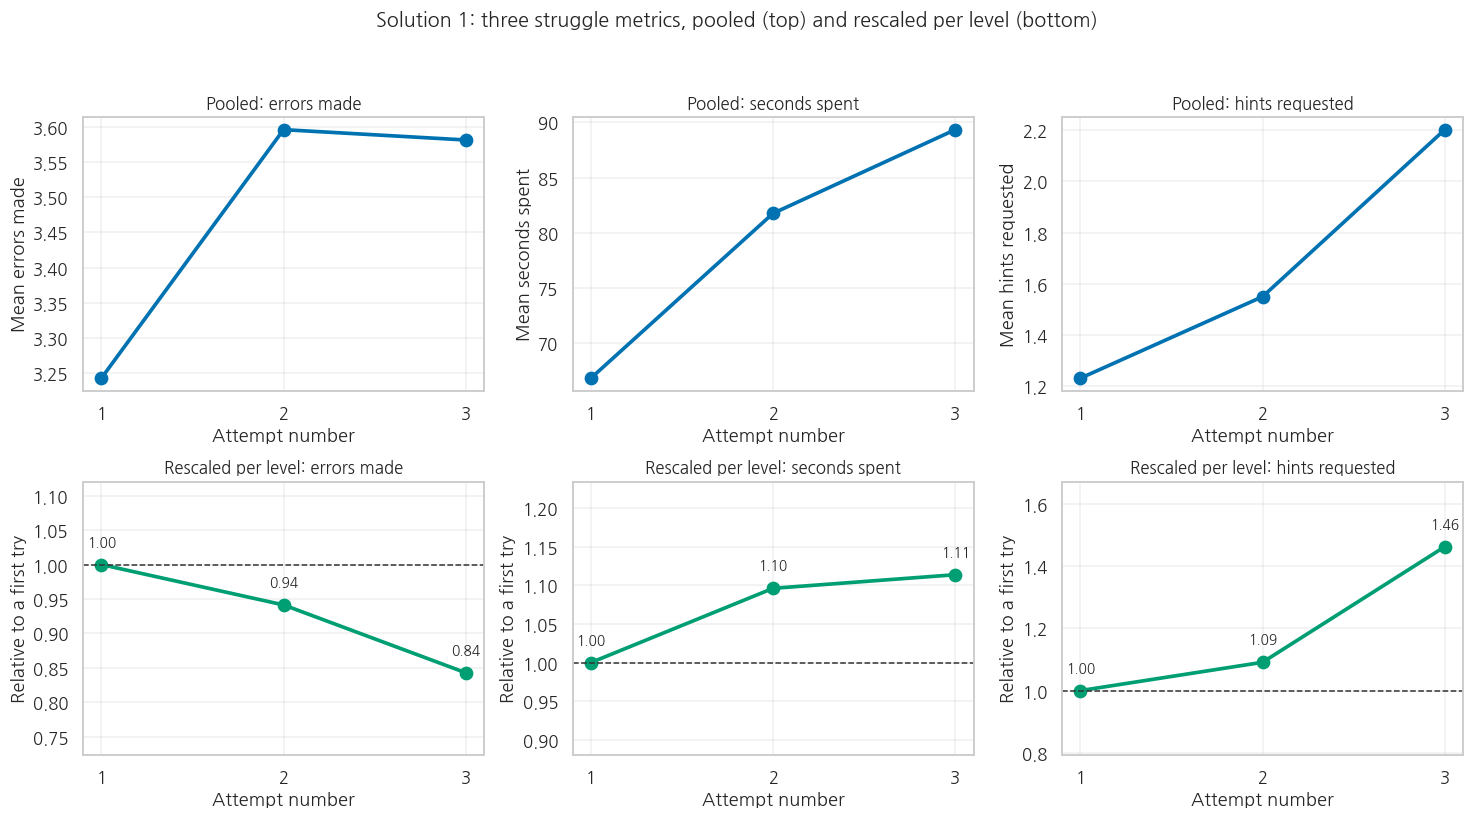

In [18]:
metrics = ['errors', 'time_s', 'hints_used']
fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.4))
for j, m in enumerate(metrics):
    sol = telemetry[telemetry['attempt'] <= 3].copy()
    base_m = telemetry[telemetry['attempt'] == 1].groupby('level')[m].mean()
    sol['rel'] = sol[m] / sol['level'].map(base_m)

    p = sol.groupby('attempt')[m].mean()
    axes[0, j].plot(p.index, p.values, marker='o', color=BLUE, linewidth=2.4, markersize=8)
    axes[0, j].set_title('Pooled: %s' % LABELS[m])
    axes[0, j].set_xlabel('Attempt number')
    axes[0, j].set_ylabel('Mean %s' % LABELS[m])
    axes[0, j].set_xticks([1, 2, 3])

    r_m = sol.groupby('attempt')['rel'].mean()
    axes[1, j].plot(r_m.index, r_m.values, marker='o', color=GREEN, linewidth=2.4, markersize=8)
    axes[1, j].axhline(1.0, color=BLACK, linestyle='--', linewidth=1)
    axes[1, j].set_title('Rescaled per level: %s' % LABELS[m])
    axes[1, j].set_xlabel('Attempt number')
    axes[1, j].set_ylabel('Relative to a first try')
    axes[1, j].set_xticks([1, 2, 3])
    lo_y, hi_y = min(r_m.min(), 1.0), max(r_m.max(), 1.0)
    pad = max(0.12, (hi_y - lo_y) * 0.45)
    axes[1, j].set_ylim(lo_y - pad, hi_y + pad)
    for a, v in r_m.items():
        axes[1, j].annotate('%.2f' % v, (a, v), textcoords='offset points', xytext=(0, 12),
                            ha='center', fontsize=9)

fig.suptitle('Solution 1: three struggle metrics, pooled (top) and rescaled per level (bottom)',
             fontsize=13, y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Read this one carefully, because it does not say what you probably expected.

All three **pooled** curves rise. Rescaling per level fixes exactly one of them. **Errors** fall to 0.84 of a first try, which is the learning curve we wanted. **Seconds** rise to 1.11 and **hints** rise to 1.46, and rescaling does not touch that.

So the composition problem was real for errors and it was never the whole story for the other two. A child on their third attempt at a level is making fewer mistakes while spending more time and pulling more hints. That is not a contradiction, it is a description: they slowed down and asked for help, and the mistakes went down.

Two things follow.

1. "Struggle" is not one variable. Errors, time, and hint use point in different directions on the same 1,428 attempts, so any composite "struggle score" you build is a weighting decision you will have to defend.
2. The lesson from section 2 stands, but state it precisely. Pooling across levels is what made the errors curve rise. It is not what made the time and hint curves rise. Do not use one diagnosis for every symptom.

### Solution 2: rank every level by how far it stands out

Rather than checking one level at a time, score all six interior levels on all four signals and sort.

Every interior level, expressed as a ratio to its two neighbours:
       mean_errors  attempts_per_player  completion_rate  mean_time_s  cliff_score
level                                                                             
4            1.724                1.339            0.682        1.666        1.549
7            0.987                1.063            0.949        0.963        1.017
6            0.991                0.945            1.032        1.040        0.986
2            0.983                0.965            1.038        0.976        0.972
3            0.747                0.882            1.098        0.782        0.830
5            0.751                0.839            1.275        0.714        0.772


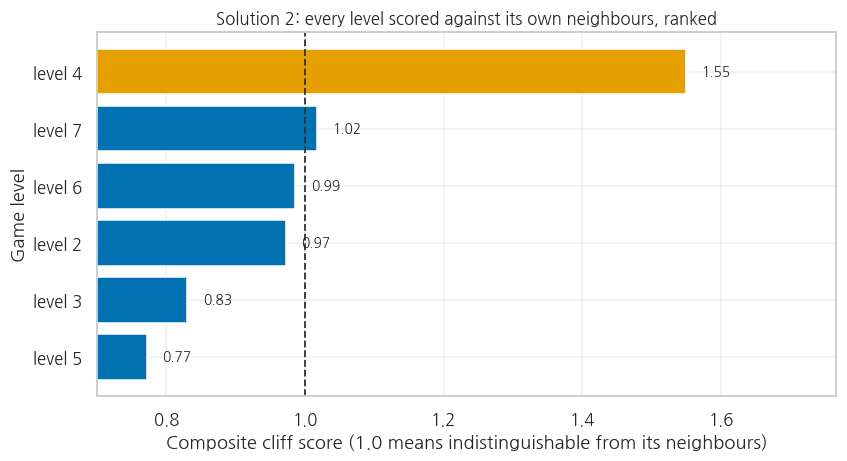

In [19]:
rows = []
for lv in range(2, 8):
    nb = [lv - 1, lv + 1]
    row = {'level': lv}
    for col in ['mean_errors', 'attempts_per_player', 'completion_rate', 'mean_time_s']:
        row[col] = level_summary.loc[lv, col] / level_summary.loc[nb, col].mean()
    # A cliff means errors, retries and time up, completion down, so invert completion.
    row['cliff_score'] = (row['mean_errors'] + row['attempts_per_player'] + row['mean_time_s']
                          + (1 / row['completion_rate'])) / 4
    rows.append(row)

ranked = pd.DataFrame(rows).set_index('level').sort_values('cliff_score', ascending=False)
print('Every interior level, expressed as a ratio to its two neighbours:')
print(ranked.round(3).to_string())

fig, ax = plt.subplots(figsize=(7.8, 4.3))
colors = [ORANGE if lv == ranked.index[0] else BLUE for lv in ranked.index]
ax.barh(['level %d' % i for i in ranked.index], ranked['cliff_score'], color=colors, edgecolor='white')
ax.axvline(1.0, color=BLACK, linestyle='--', linewidth=1.2)
for i, v in enumerate(ranked['cliff_score']):
    ax.text(v + 0.022, i, '%.2f' % v, va='center', fontsize=9)
ax.set_xlabel('Composite cliff score (1.0 means indistinguishable from its neighbours)')
ax.set_ylabel('Game level')
ax.set_title('Solution 2: every level scored against its own neighbours, ranked')
ax.set_xlim(0.7, ranked['cliff_score'].max() * 1.14)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Level 4 wins by a wide margin, and level 7 is a distant second. The composite is a convenience, not a statistic: it averages four ratios that are not on the same scale. It is useful for ranking and useless for reporting a magnitude, which is a fair description of most composite indices you will meet.

### Solution 3: the whole threshold surface, not one point on it

One setting at a time is exploring. For an argument, sweep the two error thresholds and look at what the finding does across all of them.

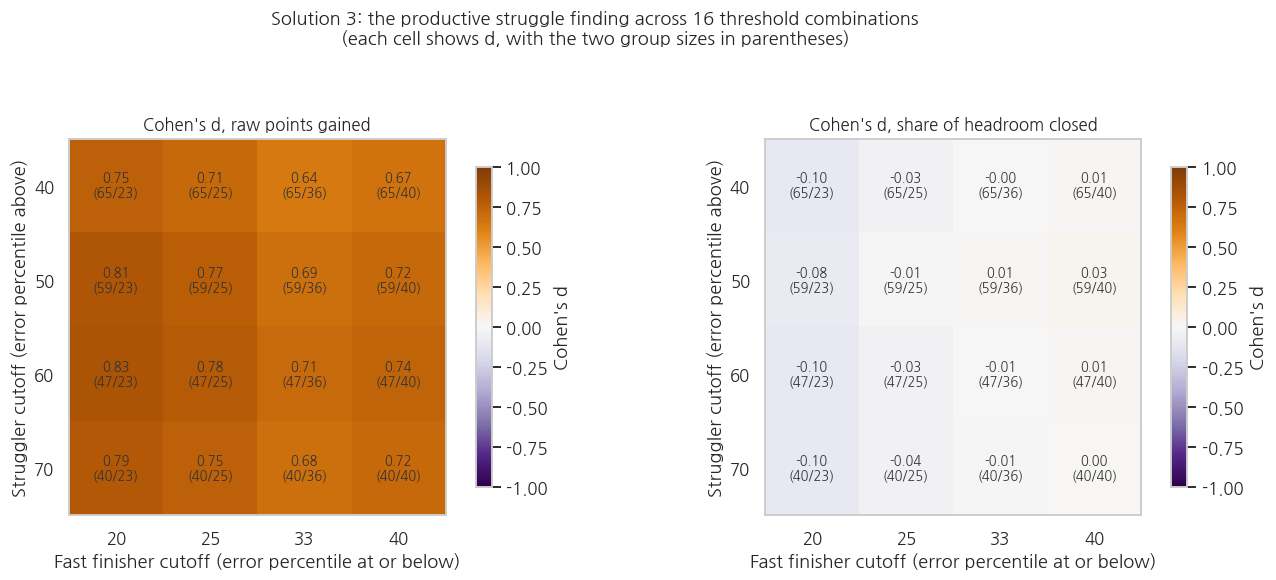

Raw-points d    : min +0.64, max +0.83
Headroom-gain d : min -0.10, max +0.03


In [20]:
hi_grid = [0.40, 0.50, 0.60, 0.70]
lo_grid = [0.20, 0.25, 0.33, 0.40]

raw_grid  = np.full((len(hi_grid), len(lo_grid)), np.nan)
head_grid = np.full((len(hi_grid), len(lo_grid)), np.nan)
n_grid    = np.empty((len(hi_grid), len(lo_grid)), dtype=object)

base_pop = play[play['max_level'] >= 4].copy()
base_pop['headroom_gain'] = base_pop['gain'] / (20 - base_pop['pre_score'])

for i, hp in enumerate(hi_grid):
    for j, lp in enumerate(lo_grid):
        hi_v, lo_v = base_pop['errors_1_4'].quantile(hp), base_pop['errors_1_4'].quantile(lp)
        a = base_pop[(base_pop['errors_1_4'] > hi_v) & (base_pop['retries_1_4'] >= 1)]
        b = base_pop[(base_pop['errors_1_4'] <= lo_v) & (base_pop['retries_1_4'] == 0)]
        n_grid[i, j] = '%d/%d' % (len(a), len(b))
        if len(a) >= 5 and len(b) >= 5:
            raw_grid[i, j]  = cohens_d(a['gain'], b['gain'])
            head_grid[i, j] = cohens_d(a['headroom_gain'], b['headroom_gain'])

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
for ax, grid, title in [(axes[0], raw_grid, "Cohen's d, raw points gained"),
                        (axes[1], head_grid, "Cohen's d, share of headroom closed")]:
    im = ax.imshow(grid, cmap='PuOr_r', vmin=-1.0, vmax=1.0)
    ax.set_xticks(range(len(lo_grid)))
    ax.set_xticklabels(['%.0f' % (100 * p) for p in lo_grid])
    ax.set_yticks(range(len(hi_grid)))
    ax.set_yticklabels(['%.0f' % (100 * p) for p in hi_grid])
    ax.set_xlabel('Fast finisher cutoff (error percentile at or below)')
    ax.set_ylabel('Struggler cutoff (error percentile above)')
    ax.set_title(title)
    ax.grid(False)
    for i in range(len(hi_grid)):
        for j in range(len(lo_grid)):
            v = grid[i, j]
            txt = 'n/a' if np.isnan(v) else '%.2f\n(%s)' % (v, n_grid[i, j])
            ax.text(j, i, txt, ha='center', va='center', fontsize=8.5, color=BLACK)
    fig.colorbar(im, ax=ax, shrink=0.85, label="Cohen's d")

fig.suptitle('Solution 3: the productive struggle finding across 16 threshold combinations\n'
             '(each cell shows d, with the two group sizes in parentheses)', fontsize=12, y=1.08)
plt.tight_layout()
plt.show()

print('Raw-points d    : min %+.2f, max %+.2f' % (np.nanmin(raw_grid), np.nanmax(raw_grid)))
print('Headroom-gain d : min %+.2f, max %+.2f' % (np.nanmin(head_grid), np.nanmax(head_grid)))

The left panel is uniformly positive and reasonably stable: the raw-points finding is not an artifact of one cutoff. The right panel hovers near zero everywhere. Both conclusions survive the sweep, which is exactly what you want to be able to say in a methods section and exactly what a single reported threshold cannot tell you.

Note the palette: purple and orange, not red and green. A colleague with deuteranopia has to be able to read your heatmap.

### Solution 4: the resolution window, swept, and the headroom check on confusion

Two things at once. First, how the confusion finding behaves across every plausible window. Second, the question the section 5.3 prompt asked you to predict: does the resolved-versus-unresolved gap survive a headroom adjustment, the way the productive struggle gap did not?

Confusion resolution finding across four windows:
        n_resolved  n_unresolved  gain_resolved  gain_unresolved  pre_resolved  pre_unresolved  d_raw_gain  d_headroom_gain  quit_resolved  quit_unresolved
window                                                                                                                                                     
1               97            89          3.773            2.371        11.412          10.191       0.569            0.617          0.361            0.787
2               73           113          3.781            2.664        11.630          10.310       0.446            0.552          0.342            0.708
3               49           137          3.837            2.839        12.224          10.328       0.395            0.717          0.327            0.650
4               44           142          3.750            2.901        12.205          10.401       0.334            0.645          0.364            0.627


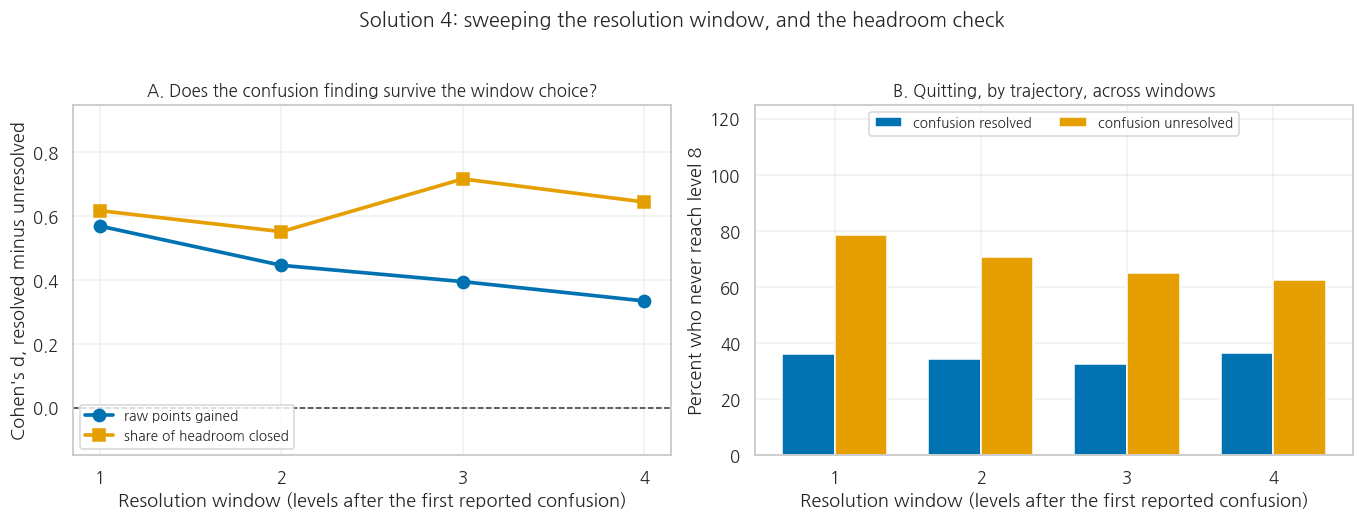

In [21]:
players_emotion['headroom_gain'] = ((players_emotion['post_score'] - players_emotion['pre_score'])
                                    / (20 - players_emotion['pre_score']))

sweep = []
for w in [1, 2, 3, 4]:
    t = players_emotion.copy()
    t['pattern'] = t['player_id'].apply(lambda p, w=w: confusion_pattern(p, window=w))
    t = t[t['pattern'] != 'never reported confusion']
    r_grp = t[t['pattern'] == 'confusion resolved']
    o_grp = t[t['pattern'] != 'confusion resolved']
    sweep.append({
        'window': w,
        'n_resolved': len(r_grp),
        'n_unresolved': len(o_grp),
        'gain_resolved': r_grp['gain'].mean(),
        'gain_unresolved': o_grp['gain'].mean(),
        'pre_resolved': r_grp['pre_score'].mean(),
        'pre_unresolved': o_grp['pre_score'].mean(),
        'd_raw_gain': cohens_d(r_grp['gain'], o_grp['gain']),
        'd_headroom_gain': cohens_d(r_grp['headroom_gain'], o_grp['headroom_gain']),
        'quit_resolved': r_grp['quit_before_level_8'].mean(),
        'quit_unresolved': o_grp['quit_before_level_8'].mean(),
    })
sweep = pd.DataFrame(sweep).set_index('window')
print('Confusion resolution finding across four windows:')
print(sweep.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))

ax = axes[0]
ax.plot(sweep.index, sweep['d_raw_gain'], marker='o', color=BLUE, linewidth=2.4,
        markersize=8, label='raw points gained')
ax.plot(sweep.index, sweep['d_headroom_gain'], marker='s', color=ORANGE, linewidth=2.4,
        markersize=8, label='share of headroom closed')
ax.axhline(0, color=BLACK, linestyle='--', linewidth=1)
ax.set_xticks([1, 2, 3, 4])
ax.set_xlabel('Resolution window (levels after the first reported confusion)')
ax.set_ylabel("Cohen's d, resolved minus unresolved")
ax.set_title('A. Does the confusion finding survive the window choice?')
ax.legend(loc='lower left', fontsize=9, frameon=True)
ax.set_ylim(-0.15, 0.95)

ax = axes[1]
w = 0.36
ax.bar(sweep.index - w / 2, 100 * sweep['quit_resolved'], width=w, color=BLUE,
       edgecolor='white', label='confusion resolved')
ax.bar(sweep.index + w / 2, 100 * sweep['quit_unresolved'], width=w, color=ORANGE,
       edgecolor='white', label='confusion unresolved')
ax.set_xticks([1, 2, 3, 4])
ax.set_xlabel('Resolution window (levels after the first reported confusion)')
ax.set_ylabel('Percent who never reach level 8')
ax.set_title('B. Quitting, by trajectory, across windows')
ax.set_ylim(0, 125)
ax.legend(loc='upper center', ncol=2, fontsize=9, frameon=True)

fig.suptitle('Solution 4: sweeping the resolution window, and the headroom check', fontsize=13, y=1.04)
plt.tight_layout()
plt.show()

Two things to take from this.

The **raw gain** gap shrinks steadily as the window widens, from d = 0.57 at a window of 1 to d = 0.33 at a window of 4, because a wider window pulls more and more children into "unresolved" until the two groups barely differ. That is not the finding weakening under scrutiny, it is the definition dissolving. A window of 1 or 2 is where the construct still means something.

Now the part worth arguing about. The **headroom** version of the confusion finding does not collapse the way the productive struggle finding did in section 4.1. It sits at or above the raw version at every window (0.55 to 0.72). The ceiling explanation that dissolved one finding leaves the other standing, and the reason is in the group means: the resolved and unresolved groups differ on the pre-test by about 1.3 points, while the strugglers and fast finishers differed by 4.5. Both the ceiling and regression to the mean scale with the size of that pre-test gap, which is why a gap a third as large does a fraction as much damage. Write one sentence about why both arguments bite harder on one finding than on the other, and bring it to the discussion.

The quitting gap in Panel B is the sturdiest thing in this whole section. It barely moves across windows, and it is the finding a game designer would actually act on.

---

*EDIS 8100: Teaching and Learning Analytics. Course design and data universe by Dr. Hakeoung Hannah Lee, University of Virginia School of Education and Human Development. All data in this notebook are synthetic: no child was measured to make it.*